# ============================================================
# SESIÓN 5: ACTIVIDAD - Optimizar todos los periodos y forecasting final
# ============================================================
### Objetivo: Explorar diferentes configuraciones de
### parámetros para encontrar la combinación óptima que maximice
### la mejora del TDA en forecasting de precios de berries.


### 1. Responde las preguntas en cada sección 
### 2. Modifica los parámetros en las celdas de experimentos
### 3. Compara resultados y saca conclusiones
### 4. No se entrega pero  representa una parte de su entregable final junto a su reporte. 
# ============================================================
**Autor:** Dr. Hugo García Tecocoatzi 

In [ ]:
# ============================================================
#  CONFIGURACIÓN INICIAL 
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# TDA
from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


Total de registros: 215
Periodo: 2008-06-01T00:00:00.000000 a 2026-04-01T00:00:00.000000

Estadísticas básicas:
  Media: 142.47
  Std: 44.71
  Min: 69.20
  Max: 299.38


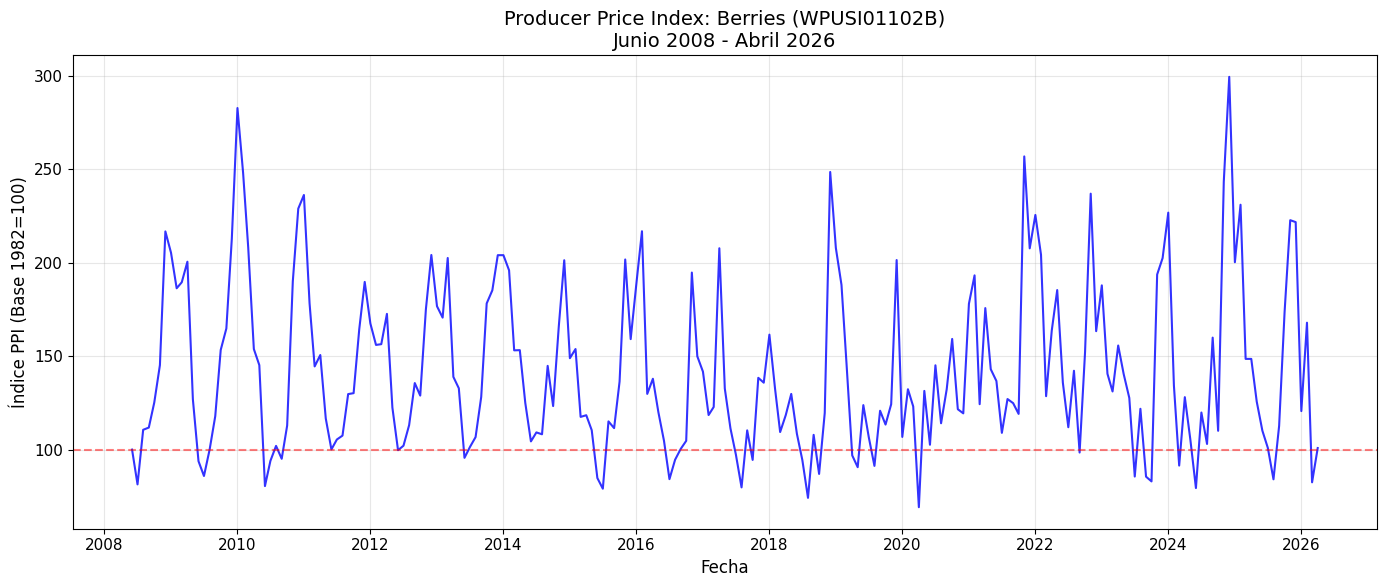

In [ ]:
# ============================================================
# CARGAR  Y VISUALIZAR DE DATOS
# ============================================================

df = pd.read_csv('../data/input/WPUSI01102B.csv', parse_dates=['observation_date'])
precios = df['WPUSI01102B'].values.astype(float)
fechas = df['observation_date'].values

print(f"Total de registros: {len(precios)}")
print(f"Periodo: {fechas[0]} a {fechas[-1]}")
print(f"\nEstadísticas básicas:")
print(f"  Media: {precios.mean():.2f}")
print(f"  Std: {precios.std():.2f}")
print(f"  Min: {precios.min():.2f}")
print(f"  Max: {precios.max():.2f}")

# Visualización de la serie completa
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(fechas, precios, 'b-', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Índice PPI (Base 1982=100)', fontsize=12)
ax.set_title('Producer Price Index: Berries (WPUSI01102B)\nJunio 2008 - Abril 2026', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Base 1982=100')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  PREGUNTAS INICIAL SOBRE LOS DATOS
# ============================================================

print("="*80)
print("PREGUNTAS: ANÁLISIS DE LA SERIE")
print("="*80)

print("""
Observa el gráfico de la serie de precios de berries y responde:

1. ¿Qué patrón estacional observas? ¿En qué meses parecen ocurrir los picos?

2. ¿Cuál es el rango aproximado de precios? ¿Ha habido tendencia al alza?

3. ¿Qué periodos muestran mayor volatilidad?

4. ¿Por qué crees que predecir esta serie puede ser un desafío?

 
""")

PREGUNTAS: ANÁLISIS DE LA SERIE

Observa el gráfico de la serie de precios de berries y responde:

1. ¿Qué patrón estacional observas? ¿En qué meses parecen ocurrir los picos?

2. ¿Cuál es el rango aproximado de precios? ¿Ha habido tendencia al alza?

3. ¿Qué periodos muestran mayor volatilidad?

4. ¿Por qué crees que predecir esta serie puede ser un desafío?





Periodo de entrenamiento: 2013-2019 (84 meses)
Periodo de prueba: 2020-2022 (36 meses)


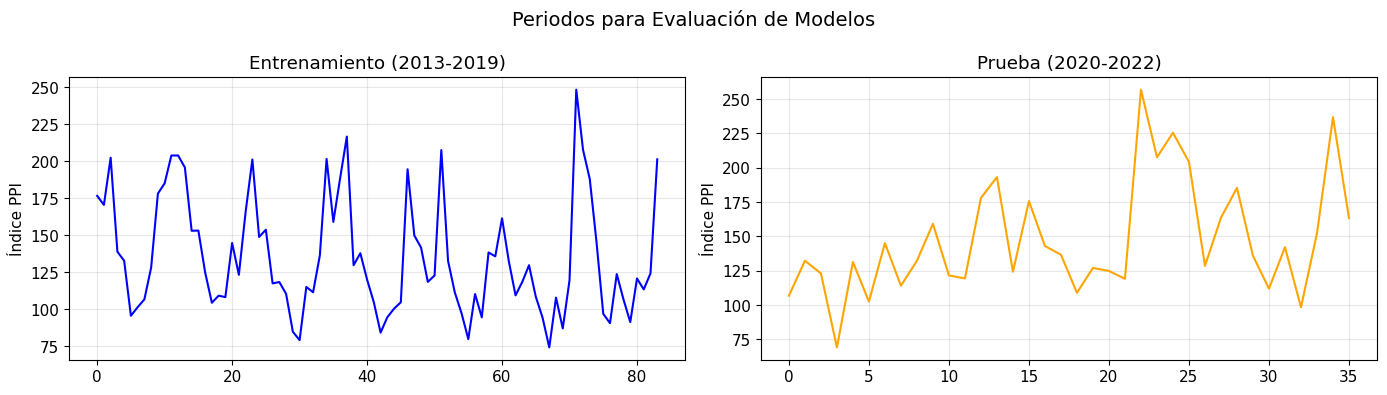

In [ ]:
# ============================================================
# 4. DEFINICIÓN DE PERIODOS PARA EVALUACIÓN 
# ============================================================

periodos_entrenamiento = {
    '2008-2012': ('2008-06-01', '2012-12-31'),
    '2013-2019': ('2013-01-01', '2019-12-31'),
    '2020-2022': ('2020-01-01', '2022-12-31'),
    '2023-2024': ('2023-01-01', '2024-12-31')
}

def extraer_datos_por_fecha(inicio, fin):
    if inicio is None:
        mask = np.ones(len(precios), dtype=bool)
    else:
        mask = (fechas >= np.datetime64(inicio)) & (fechas <= np.datetime64(fin))
    return precios[mask], fechas[mask]

# Para los experimentos usaremos un periodo fijo, por ejemplo:
signal_entreno, _ = extraer_datos_por_fecha('2013-01-01', '2019-12-31')
signal_prueba, _ = extraer_datos_por_fecha('2020-01-01', '2022-12-31')

print(f"Periodo de entrenamiento: 2013-2019 ({len(signal_entreno)} meses)")
print(f"Periodo de prueba: 2020-2022 ({len(signal_prueba)} meses)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(signal_entreno, 'b-', linewidth=1.5)
axes[0].set_title('Entrenamiento (2013-2019)')
axes[0].set_ylabel('Índice PPI')
axes[0].grid(True, alpha=0.3)

axes[1].plot(signal_prueba, 'orange', linewidth=1.5)
axes[1].set_title('Prueba (2020-2022)')
axes[1].set_ylabel('Índice PPI')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Periodos para Evaluación de Modelos', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FUNCIÓN BASE PARA FORECASTING 
# ============================================================

def entrenar_y_evaluar(signal_entreno, signal_prueba, 
                       window_size=24, embedding_dim=6, time_delay=3,
                       use_tda=True):
    """
    Entrena un modelo y evalúa en periodo de prueba.
    
    Parámetros:
    - window_size: tamaño de la ventana deslizante (meses)
    - embedding_dim: dimensión del embedding de Takens
    - time_delay: retardo del embedding
    - use_tda: si usar características topológicas
    
    Retorna:
    - mae: Error Absoluto Medio
    - rmse: Raíz del Error Cuadrático Medio
    - r2: Coeficiente de Determinación
    - mejora: mejora porcentual vs baseline (si use_tda=True)
    """
    
    # Sliding window para entrenamiento
    SW = SlidingWindow(size=window_size, stride=1)
    X_signal = signal_entreno.reshape(-1, 1)
    X_windows, y_train = SW.fit_transform_resample(X_signal, signal_entreno)
    
    if use_tda:
        # Extraer características topológicas
        STE = SingleTakensEmbedding(
            parameters_type="fixed",
            dimension=embedding_dim,
            time_delay=time_delay
        )
        VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1, collapse_edges=True)
        
        topo_features = []
        for i in range(X_windows.shape[0]):
            window_1d = X_windows[i].flatten()
            try:
                embedding = STE.fit_transform(window_1d)
                if len(embedding) >= 5:
                    diagrams = VR.fit_transform([embedding])[0]
                    mask = diagrams[:, 2] == 1
                    if np.any(mask):
                        persistences = diagrams[mask, 1] - diagrams[mask, 0]
                        max_pers = np.max(persistences)
                        mean_pers = np.mean(persistences)
                        std_pers = np.std(persistences)
                        n_cycles = len(persistences)
                    else:
                        max_pers = mean_pers = std_pers = n_cycles = 0
                    topo_features.append([max_pers, mean_pers, std_pers, n_cycles])
                else:
                    topo_features.append([0, 0, 0, 0])
            except:
                topo_features.append([0, 0, 0, 0])
        
        topo_features = np.array(topo_features)
        
        # Normalizar y combinar
        scaler_raw = StandardScaler()
        scaler_topo = StandardScaler()
        X_raw_norm = scaler_raw.fit_transform(X_windows.reshape(-1, window_size))
        X_topo_norm = scaler_topo.fit_transform(topo_features)
        X_train = np.hstack([X_raw_norm, X_topo_norm])
    else:
        X_train = X_windows.reshape(-1, window_size)
        scaler_raw = StandardScaler()
        X_train = scaler_raw.fit_transform(X_train)
    
    # Entrenar Random Forest
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, 
                               min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Predicción recursiva
    preds = []
    current_window = signal_entreno[-window_size:].copy()
    
    for i in range(len(signal_prueba)):
        if use_tda:
            try:
                STE_pred = SingleTakensEmbedding(
                    parameters_type="fixed", dimension=embedding_dim, time_delay=time_delay)
                VR_pred = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1, collapse_edges=True)
                
                embedding = STE_pred.fit_transform(current_window)
                if len(embedding) >= 5:
                    diagrams = VR_pred.fit_transform([embedding])[0]
                    mask = diagrams[:, 2] == 1
                    if np.any(mask):
                        persistences = diagrams[mask, 1] - diagrams[mask, 0]
                        max_pers = np.max(persistences)
                        mean_pers = np.mean(persistences)
                        std_pers = np.std(persistences)
                        n_cycles = len(persistences)
                    else:
                        max_pers = mean_pers = std_pers = n_cycles = 0
                    topo_feat = np.array([max_pers, mean_pers, std_pers, n_cycles]).reshape(1, -1)
                else:
                    topo_feat = np.array([[0, 0, 0, 0]])
                
                current_raw_norm = scaler_raw.transform(current_window.reshape(1, -1))
                current_topo_norm = scaler_topo.transform(topo_feat)
                x_pred = np.hstack([current_raw_norm, current_topo_norm])
            except:
                x_pred = scaler_raw.transform(current_window.reshape(1, -1))
        else:
            x_pred = scaler_raw.transform(current_window.reshape(1, -1))
        
        pred = rf.predict(x_pred)[0]
        preds.append(pred)
        
        if i < len(signal_prueba) - 1:
            current_window = np.roll(current_window, -1)
            current_window[-1] = signal_prueba[i]
    
    mae = mean_absolute_error(signal_prueba, preds)
    rmse = np.sqrt(mean_squared_error(signal_prueba, preds))
    r2 = r2_score(signal_prueba, preds)
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'preds': preds}

print("✅ Función de entrenamiento y evaluación definida")

✅ Función de entrenamiento y evaluación definida


EXPERIMENTO BASE: Modelo SIN Características Topológicas

🔹 Resultados Baseline (sin TDA):
   MAE:  37.6931
   RMSE: 48.1850
   R²:   -0.3799


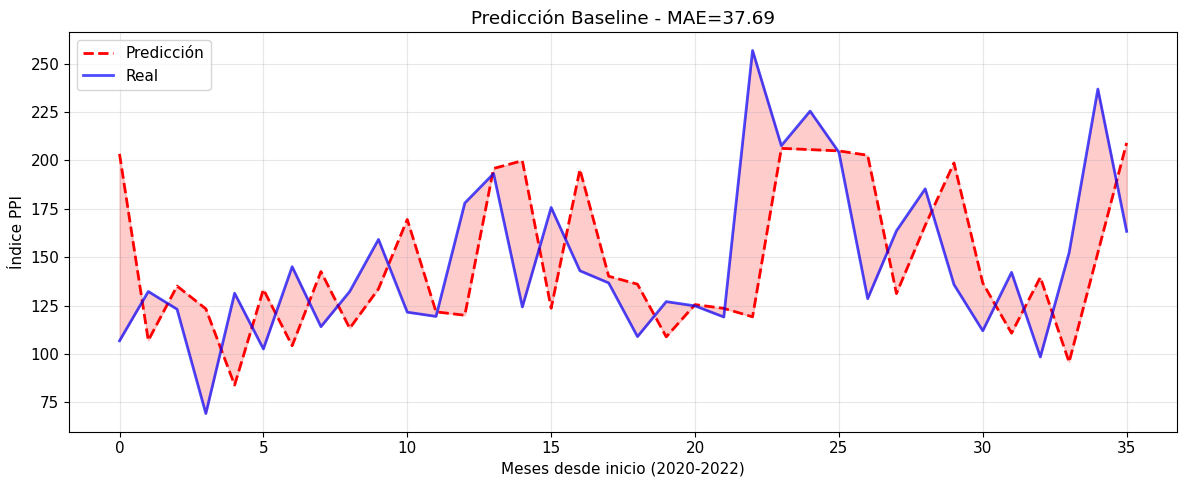

In [ ]:
# ============================================================
# EXPERIMENTO BASE: SIN TDA (BASELINE)
# ============================================================

print("="*80)
print("EXPERIMENTO BASE: Modelo SIN Características Topológicas")
print("="*80)

# Ejecutar baseline
resultado_base = entrenar_y_evaluar(signal_entreno, signal_prueba, 
                                    window_size=24, use_tda=False)

print(f"\n🔹 Resultados Baseline (sin TDA):")
print(f"   MAE:  {resultado_base['mae']:.4f}")
print(f"   RMSE: {resultado_base['rmse']:.4f}")
print(f"   R²:   {resultado_base['r2']:.4f}")

# Visualizar predicción
plt.figure(figsize=(12, 5))
plt.plot(resultado_base['preds'], 'r--', label='Predicción', linewidth=2)
plt.plot(signal_prueba, 'b-', label='Real', linewidth=2, alpha=0.7)
plt.fill_between(range(len(signal_prueba)), signal_prueba, resultado_base['preds'], alpha=0.2, color='red')
plt.xlabel('Meses desde inicio (2020-2022)')
plt.ylabel('Índice PPI')
plt.title(f'Predicción Baseline - MAE={resultado_base["mae"]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  ¿QUÉ PARÁMETROS DEBEMOS OPTIMIZAR?
# ============================================================

print("="*80)
print("PREGUNTA: PARÁMETROS CLAVE DEL TDA")
print("="*80)

print("""
El TDA introduce nuevos parámetros que debemos ajustar:

1. WINDOW_SIZE (tamaño de ventana):
   - ¿Cuántos puntos del pasado usamos para predecir?
   - ¿Cuál es el ciclo natural de los precios de berries?
   - Prueba: 6, 12, 18, 24, 36 meses

2. EMBEDDING_DIM (dimensión del embedding):
   - ¿Cuántos retardos usamos en el embedding?
   - Regla: debe ser menor que window_size/3
   - Prueba: 2, 3, 4, 5

3. TIME_DELAY (retardo entre puntos):
   - ¿Qué separación entre puntos del embedding?
   - Para datos mensuales, τ=1 o τ=2 debería ser óptimo

REFLEXIÓN:
   ¿Qué esperas que pase si usas una ventana demasiado pequeña?
   ¿Y si usas una ventana demasiado grande?
   ¿Qué relación hay entre embedding_dim y window_size?


""")

PREGUNTA: PARÁMETROS CLAVE DEL TDA

El TDA introduce nuevos parámetros que debemos ajustar:

1. WINDOW_SIZE (tamaño de ventana):
   - ¿Cuántos puntos del pasado usamos para predecir?
   - ¿Cuál es el ciclo natural de los precios de berries?
   - Prueba: 6, 12, 18, 24, 36 meses

2. EMBEDDING_DIM (dimensión del embedding):
   - ¿Cuántos retardos usamos en el embedding?
   - Regla: debe ser menor que window_size/3
   - Prueba: 2, 3, 4, 5

3. TIME_DELAY (retardo entre puntos):
   - ¿Qué separación entre puntos del embedding?
   - Para datos mensuales, τ=1 o τ=2 debería ser óptimo

REFLEXIÓN:
   ¿Qué esperas que pase si usas una ventana demasiado pequeña?
   ¿Y si usas una ventana demasiado grande?
   ¿Qué relación hay entre embedding_dim y window_size?





## Vamos a ver los demás periodos

In [ ]:
# ============================================================
# 8. ACTIVIDAD 1: EXPLORAR DIFERENTES WINDOW_SIZES
# (Evaluando en TODOS los periodos) 
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?")
print("="*80)

# Definir todos los pares entrenamiento-prueba
pares_periodos = [
    ('2008-2012', '2013-2019', 'Periodo Post-Crisis'),
    ('2013-2019', '2020-2022', 'Periodo Pandemia'),
    ('2020-2022', '2023-2024', 'Periodo Post-Pandemia'),
    ('2008-2012', '2020-2022', 'Salto Crisis→Pandemia'),
    ('2013-2019', '2023-2024', 'Estable→Reciente'),
]

# Valores a explorar
window_sizes = [6, 12, 18, 24, 30, 36]
resultados_totales_windows = {}
mejores_windows_por_periodo = {}  # Guardar el mejor window para cada periodo

print("\nEvaluando diferentes window_sizes en TODOS los periodos:")
print("="*70)

for nombre_entreno, nombre_prueba, descripcion in pares_periodos:
    print(f"\n📊 {descripcion}: {nombre_entreno} → {nombre_prueba}")
    print("-"*50)
    
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    resultados_por_window = []
    
    for ws in window_sizes:
        # Baseline
        base = entrenar_y_evaluar(signal_entreno, signal_prueba, 
                                  window_size=ws, use_tda=False)
        
        # Con TDA (parámetros fijos para comparar solo window)
        tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=ws, embedding_dim=3, time_delay=1,
                                 use_tda=True)
        
        mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
        
        resultados_por_window.append({
            'window': ws,
            'baseline_mae': base['mae'],
            'tda_mae': tda['mae'],
            'mejora': mejora
        })
        
        estado = "✅" if mejora > 0 else "❌"
        print(f"   Window={ws:2d}: {estado} Mejora={mejora:+6.2f}% | Base MAE={base['mae']:.2f} → TDA={tda['mae']:.2f}")
    
    resultados_totales_windows[descripcion] = resultados_por_window
    
    # Guardar el mejor window para este periodo
    mejor = max(resultados_por_window, key=lambda x: x['mejora'])
    mejores_windows_por_periodo[descripcion] = mejor['window']
    print(f"   → MEJOR WINDOW para este periodo: {mejor['window']} meses (mejora: {mejor['mejora']:+.2f}%)")

# Mostrar mejores windows por periodo
print("\n" + "="*80)
print("📊 MEJORES WINDOW_SIZES POR PERIODO (para usar en Actividades 2 y 3)")
print("="*80)
for periodo, window in mejores_windows_por_periodo.items():
    print(f"   {periodo:<30} → window_size = {window} meses")

🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?

Evaluando diferentes window_sizes en TODOS los periodos:

📊 Periodo Post-Crisis: 2008-2012 → 2013-2019
--------------------------------------------------
   Window= 6: ✅ Mejora= +0.01% | Base MAE=26.37 → TDA=26.37
   Window=12: ✅ Mejora= +0.14% | Base MAE=26.28 → TDA=26.25
   Window=18: ❌ Mejora= -1.07% | Base MAE=25.35 → TDA=25.62
   Window=24: ❌ Mejora= -0.78% | Base MAE=23.63 → TDA=23.81
   Window=30: ✅ Mejora= +0.54% | Base MAE=23.95 → TDA=23.82
   Window=36: ❌ Mejora= -1.33% | Base MAE=25.47 → TDA=25.81
   → MEJOR WINDOW para este periodo: 30 meses (mejora: +0.54%)

📊 Periodo Pandemia: 2013-2019 → 2020-2022
--------------------------------------------------
   Window= 6: ✅ Mejora= +0.38% | Base MAE=37.77 → TDA=37.63
   Window=12: ✅ Mejora= +0.84% | Base MAE=37.38 → TDA=37.07
   Window=18: ✅ Mejora= +0.32% | Base MAE=37.49 → TDA=37.36
   Window=24: ❌ Mejora= -1.01% | Base MAE=37.69 → TDA=38.07
   Window=30: ❌ Mejora= -0.59% | Bas

🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?

Evaluando diferentes window_sizes en TODOS los periodos:

📊 Periodo Post-Crisis: 2008-2012 → 2013-2019
--------------------------------------------------
   Window= 6: ✅ Mejora= +0.01% | Base MAE=26.37 → TDA=26.37
   Window=12: ✅ Mejora= +0.47% | Base MAE=26.28 → TDA=26.16
   Window=18: ❌ Mejora= -1.36% | Base MAE=25.35 → TDA=25.69
   Window=24: ❌ Mejora= -1.20% | Base MAE=23.63 → TDA=23.91
   Window=30: ✅ Mejora= +0.69% | Base MAE=23.95 → TDA=23.79
   Window=36: ❌ Mejora= -1.80% | Base MAE=25.47 → TDA=25.93

📊 Periodo Pandemia: 2013-2019 → 2020-2022
--------------------------------------------------
   Window= 6: ✅ Mejora= +0.38% | Base MAE=37.77 → TDA=37.63
   Window=12: ✅ Mejora= +0.83% | Base MAE=37.38 → TDA=37.07
   Window=18: ✅ Mejora= +0.87% | Base MAE=37.49 → TDA=37.16
   Window=24: ❌ Mejora= -0.51% | Base MAE=37.69 → TDA=37.89
   Window=30: ❌ Mejora= -0.49% | Base MAE=37.09 → TDA=37.27
   Window=36: ✅ Mejora= +0.25% | Base M

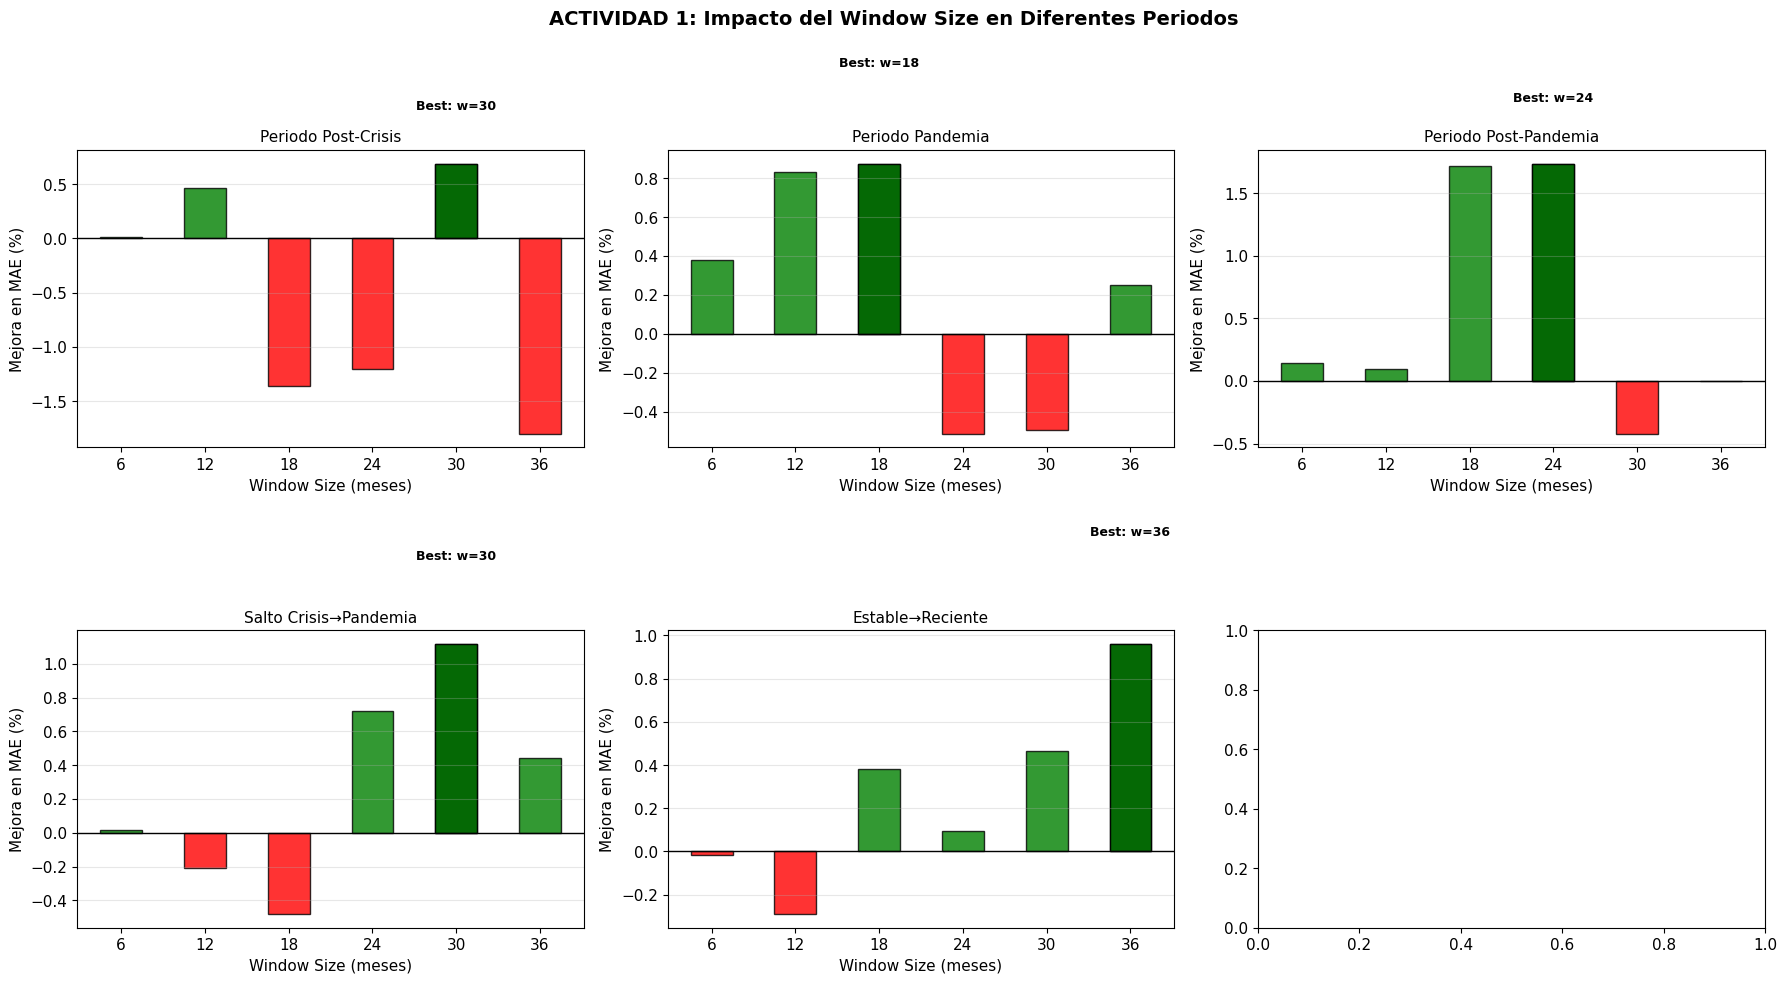


📊 RESUMEN ACTIVIDAD 1: MEJOR WINDOW_SIZE POR PERIODO

Periodo                        Mejor Window    Mejora Obtenida
------------------------------------------------------------
Periodo Post-Crisis            30 meses          +0.69%
Periodo Pandemia               18 meses          +0.87%
Periodo Post-Pandemia          24 meses          +1.73%
Salto Crisis→Pandemia          30 meses          +1.12%
Estable→Reciente               36 meses          +0.96%

📝 PREGUNTA 1: ¿Qué observas?

1. ¿El mismo window_size funciona mejor en todos los periodos?

2. ¿Qué window_size parece ser el más consistente?

3. ¿En qué periodos las ventanas pequeñas (6-12 meses) funcionan mejor?

4. ¿En qué periodos las ventanas grandes (24-36 meses) funcionan mejor?


   - 
   - 
   - 



In [ ]:
# ============================================================
#  ACTIVIDAD 1: EXPLORAR DIFERENTES WINDOW_SIZES
# (Evaluando en TODOS los periodos)
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?")
print("="*80)

# Definir todos los pares entrenamiento-prueba
pares_periodos = [
    ('2008-2012', '2013-2019', 'Periodo Post-Crisis'),
    ('2013-2019', '2020-2022', 'Periodo Pandemia'),
    ('2020-2022', '2023-2024', 'Periodo Post-Pandemia'),
    ('2008-2012', '2020-2022', 'Salto Crisis→Pandemia'),
    ('2013-2019', '2023-2024', 'Estable→Reciente'),
]

# Valores a explorar
window_sizes = [6, 12, 18, 24, 30, 36]
resultados_totales_windows = {}

print("\nEvaluando diferentes window_sizes en TODOS los periodos:")
print("="*70)

for nombre_entreno, nombre_prueba, descripcion in pares_periodos:
    print(f"\n📊 {descripcion}: {nombre_entreno} → {nombre_prueba}")
    print("-"*50)
    
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    resultados_por_window = []
    
    for ws in window_sizes:
        # Baseline
        base = entrenar_y_evaluar(signal_entreno, signal_prueba, 
                                  window_size=ws, use_tda=False)
        
        # Con TDA (parámetros fijos para comparar solo window)
        tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=ws, embedding_dim=4, time_delay=1,
                                 use_tda=True)
        
        mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
        
        resultados_por_window.append({
            'window': ws,
            'baseline_mae': base['mae'],
            'tda_mae': tda['mae'],
            'mejora': mejora
        })
        
        estado = "✅" if mejora > 0 else "❌"
        print(f"   Window={ws:2d}: {estado} Mejora={mejora:+6.2f}% | Base MAE={base['mae']:.2f} → TDA={tda['mae']:.2f}")
    
    resultados_totales_windows[descripcion] = resultados_por_window

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (descripcion, resultados) in enumerate(resultados_totales_windows.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    windows = [r['window'] for r in resultados]
    mejoras = [r['mejora'] for r in resultados]
    
    colors = ['green' if m > 0 else 'red' for m in mejoras]
    bars = ax.bar(windows, mejoras, width=3, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Window Size (meses)')
    ax.set_ylabel('Mejora en MAE (%)')
    ax.set_title(f'{descripcion}', fontsize=11)
    ax.set_xticks(windows)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Mejor window
    mejor_idx = np.argmax(mejoras)
    ax.bar(windows[mejor_idx], mejoras[mejor_idx], width=3, 
           color='darkgreen', alpha=0.9, edgecolor='black')
    ax.text(windows[mejor_idx], mejoras[mejor_idx] + 0.5, 
            f'Best: w={windows[mejor_idx]}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ACTIVIDAD 1: Impacto del Window Size en Diferentes Periodos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen de mejores window por periodo
print("\n" + "="*80)
print("📊 RESUMEN ACTIVIDAD 1: MEJOR WINDOW_SIZE POR PERIODO")
print("="*80)

print(f"\n{'Periodo':<30} {'Mejor Window':<15} {'Mejora Obtenida':<15}")
print("-"*60)

for descripcion, resultados in resultados_totales_windows.items():
    mejor = max(resultados, key=lambda x: x['mejora'])
    print(f"{descripcion:<30} {mejor['window']:2d} meses          {mejor['mejora']:+.2f}%")

print("\n" + "="*80)
print("📝 PREGUNTA 1: ¿Qué observas?")
print("="*80)
print("""
1. ¿El mismo window_size funciona mejor en todos los periodos?
   
2. ¿Qué window_size parece ser el más consistente?
   
3. ¿En qué periodos las ventanas pequeñas (6-12 meses) funcionan mejor?
   
4. ¿En qué periodos las ventanas grandes (24-36 meses) funcionan mejor?
   

   - 
   - 
   - 
""")

🔬 ACTIVIDAD 2: ¿CUÁL ES LA MEJOR DIMENSIÓN DE EMBEDDING?

Evaluando diferentes embedding_dim (usando el mejor window de cada periodo):

📊 Periodo Post-Crisis: 2008-2012 → 2013-2019
--------------------------------------------------
   Usando window_size = 30 meses (óptimo para este periodo)
   dim=1: ❌ Mejora= -0.09% | Base MAE=23.95 → TDA=23.97
   dim=2: ❌ Mejora= -0.01% | Base MAE=23.95 → TDA=23.95
   dim=3: ✅ Mejora= +0.54% | Base MAE=23.95 → TDA=23.82
   dim=4: ✅ Mejora= +0.69% | Base MAE=23.95 → TDA=23.79
   dim=5: ✅ Mejora= +0.21% | Base MAE=23.95 → TDA=23.90
   dim=6: ✅ Mejora= +0.15% | Base MAE=23.95 → TDA=23.92

📊 Periodo Pandemia: 2013-2019 → 2020-2022
--------------------------------------------------
   Usando window_size = 12 meses (óptimo para este periodo)
   dim=1: ✅ Mejora= +0.80% | Base MAE=37.38 → TDA=37.09
   dim=2: ✅ Mejora= +0.45% | Base MAE=37.38 → TDA=37.22
   dim=3: ✅ Mejora= +0.84% | Base MAE=37.38 → TDA=37.07
   dim=4: ✅ Mejora= +0.83% | Base MAE=37.38 → TDA=

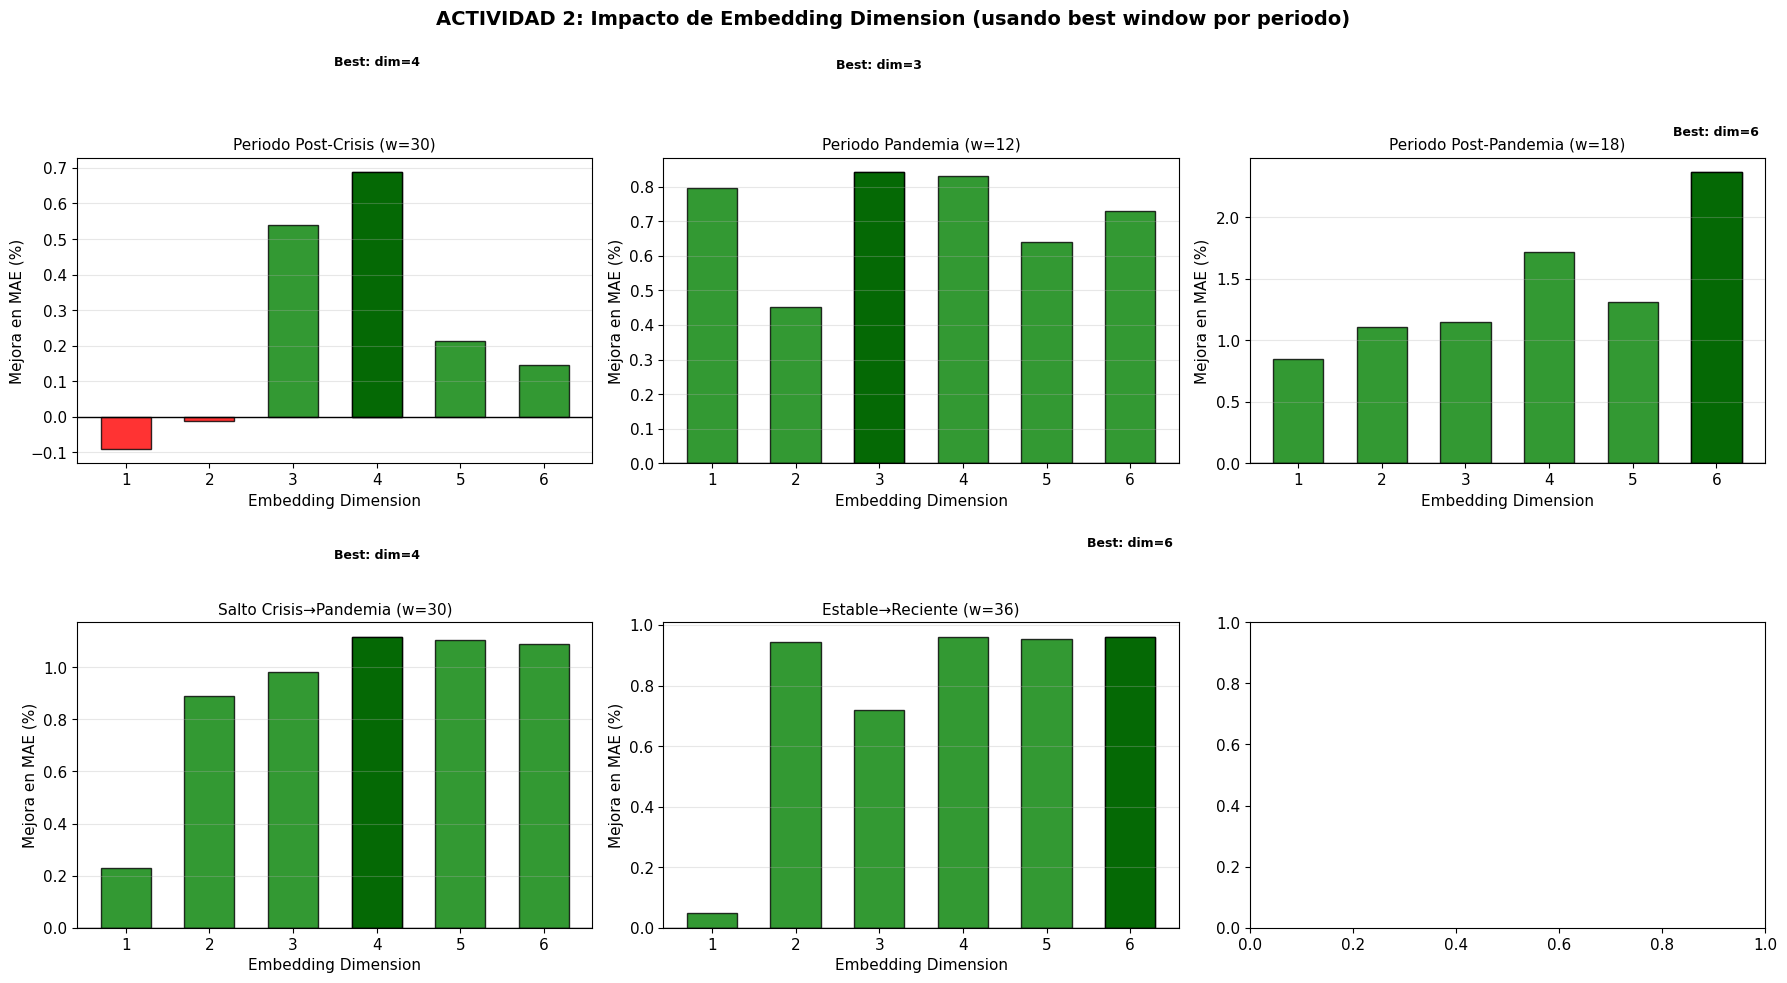


📊 RESUMEN ACTIVIDAD 2: MEJOR EMBEDDING_DIM POR PERIODO

Periodo                        Window usado    Mejor dim    Mejora Obtenida   
----------------------------------------------------------------------
Periodo Post-Crisis            30 meses          4            +0.69%
Periodo Pandemia               12 meses          3            +0.84%
Periodo Post-Pandemia          18 meses          6            +2.37%
Salto Crisis→Pandemia          30 meses          4            +1.12%
Estable→Reciente               36 meses          6            +0.96%

📝 PREGUNTA 2: ¿Qué observas sobre la dimensión de embedding?

1. ¿Qué dimensión de embedding funciona mejor en la mayoría de los periodos?

2. ¿Qué ocurre cuando la dimensión es muy alta (5 o 6)?
   (Pista: mira la regla (dim-1)*τ+1 ≤ window_size)

3. ¿Por qué las dimensiones pequeñas (2-3) tienden a funcionar mejor?

4. ¿En qué periodo la dimensión óptima es diferente? ¿Por qué crees?


RESPONDE AQUÍ:
   - 
   - 
   - 



In [ ]:
# ============================================================
# ACTIVIDAD 2: EXPLORAR EMBEDDING_DIM (USANDO MEJOR WINDOW DE CADA PERIODO)
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 2: ¿CUÁL ES LA MEJOR DIMENSIÓN DE EMBEDDING?")
print("="*80)

embedding_dims = [1, 2, 3, 4, 5, 6]
resultados_totales_dims = {}

print("\nEvaluando diferentes embedding_dim (usando el mejor window de cada periodo):")
print("="*70)

for nombre_entreno, nombre_prueba, descripcion in pares_periodos:
    print(f"\n📊 {descripcion}: {nombre_entreno} → {nombre_prueba}")
    print("-"*50)
    
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    # Usar el mejor window para este periodo (de Actividad 1)
    window_optimo = mejores_windows_por_periodo[descripcion]
    print(f"   Usando window_size = {window_optimo} meses (óptimo para este periodo)")
    
    # Baseline para este periodo (sin TDA)
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=window_optimo, use_tda=False)
    
    resultados_por_dim = []
    
    for dim in embedding_dims:
        # Verificar factibilidad: (dim-1)*τ+1 ≤ window_size
        min_points = (dim - 1) * 1 + 1
        if min_points > window_optimo:
            print(f"   dim={dim}: ⚠ Requiere {min_points} pts, ventana={window_optimo} → NO VÁLIDO")
            resultados_por_dim.append({
                'dim': dim,
                'tda_mae': np.nan,
                'mejora': np.nan,
                'valido': False
            })
            continue
        
        tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=window_optimo, 
                                 embedding_dim=dim, time_delay=1,
                                 use_tda=True)
        
        mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
        
        resultados_por_dim.append({
            'dim': dim,
            'tda_mae': tda['mae'],
            'mejora': mejora,
            'valido': True
        })
        
        estado = "✅" if mejora > 0 else "❌"
        print(f"   dim={dim}: {estado} Mejora={mejora:+6.2f}% | Base MAE={base['mae']:.2f} → TDA={tda['mae']:.2f}")
    
    resultados_totales_dims[descripcion] = {
        'window_used': window_optimo,
        'base_mae': base['mae'],
        'resultados': resultados_por_dim
    }

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (descripcion, data) in enumerate(resultados_totales_dims.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    resultados_validos = [r for r in data['resultados'] if r['valido']]
    
    if resultados_validos:
        dims = [r['dim'] for r in resultados_validos]
        mejoras = [r['mejora'] for r in resultados_validos]
        
        colors = ['green' if m > 0 else 'red' for m in mejoras]
        ax.bar(dims, mejoras, width=0.6, color=colors, alpha=0.8, edgecolor='black')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.set_xlabel('Embedding Dimension')
        ax.set_ylabel('Mejora en MAE (%)')
        ax.set_title(f'{descripcion} (w={data["window_used"]})', fontsize=11)
        ax.set_xticks(dims)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Mejor dimensión
        mejor_idx = np.argmax(mejoras)
        ax.bar(dims[mejor_idx], mejoras[mejor_idx], width=0.6, 
               color='darkgreen', alpha=0.9, edgecolor='black')
        ax.text(dims[mejor_idx], mejoras[mejor_idx] + 0.3, 
                f'Best: dim={dims[mejor_idx]}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ACTIVIDAD 2: Impacto de Embedding Dimension (usando best window por periodo)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*80)
print("📊 RESUMEN ACTIVIDAD 2: MEJOR EMBEDDING_DIM POR PERIODO")
print("="*80)

print(f"\n{'Periodo':<30} {'Window usado':<15} {'Mejor dim':<12} {'Mejora Obtenida':<18}")
print("-"*70)

mejores_dims_por_periodo = {}

for descripcion, data in resultados_totales_dims.items():
    resultados_validos = [r for r in data['resultados'] if r['valido']]
    if resultados_validos:
        mejor = max(resultados_validos, key=lambda x: x['mejora'])
        mejores_dims_por_periodo[descripcion] = mejor['dim']
        print(f"{descripcion:<30} {data['window_used']:2d} meses          {mejor['dim']:<12} {mejor['mejora']:+.2f}%")

print("\n" + "="*80)
print("📝 PREGUNTA 2: ¿Qué observas sobre la dimensión de embedding?")
print("="*80)
print("""
1. ¿Qué dimensión de embedding funciona mejor en la mayoría de los periodos?
   
2. ¿Qué ocurre cuando la dimensión es muy alta (5 o 6)?
   (Pista: mira la regla (dim-1)*τ+1 ≤ window_size)
   
3. ¿Por qué las dimensiones pequeñas (2-3) tienden a funcionar mejor?
   
4. ¿En qué periodo la dimensión óptima es diferente? ¿Por qué crees?
   

RESPONDE AQUÍ:
   - 
   - 
   - 
""")

🔬 ACTIVIDAD 3: ¿CUÁL ES EL MEJOR RETARDO (τ)?

Evaluando diferentes time_delays (usando mejor window y mejor dim de cada periodo):

📊 Periodo Post-Crisis: 2008-2012 → 2013-2019
--------------------------------------------------
   Usando window_size = 30 meses, embedding_dim = 4
   τ=1: ✅ Mejora= +0.69% | Base MAE=23.95 → TDA=23.79
   τ=2: ❌ Mejora= -0.37% | Base MAE=23.95 → TDA=24.04
   τ=3: ✅ Mejora= +0.17% | Base MAE=23.95 → TDA=23.91
   τ=4: ✅ Mejora= +0.64% | Base MAE=23.95 → TDA=23.80
   τ=5: ✅ Mejora= +0.03% | Base MAE=23.95 → TDA=23.95

📊 Periodo Pandemia: 2013-2019 → 2020-2022
--------------------------------------------------
   Usando window_size = 12 meses, embedding_dim = 3
   τ=1: ✅ Mejora= +0.84% | Base MAE=37.38 → TDA=37.07
   τ=2: ✅ Mejora= +0.51% | Base MAE=37.38 → TDA=37.19
   τ=3: ✅ Mejora= +0.57% | Base MAE=37.38 → TDA=37.17
   τ=4: ✅ Mejora= +0.80% | Base MAE=37.38 → TDA=37.09
   τ=5: ✅ Mejora= +0.80% | Base MAE=37.38 → TDA=37.09

📊 Periodo Post-Pandemia: 2020-202

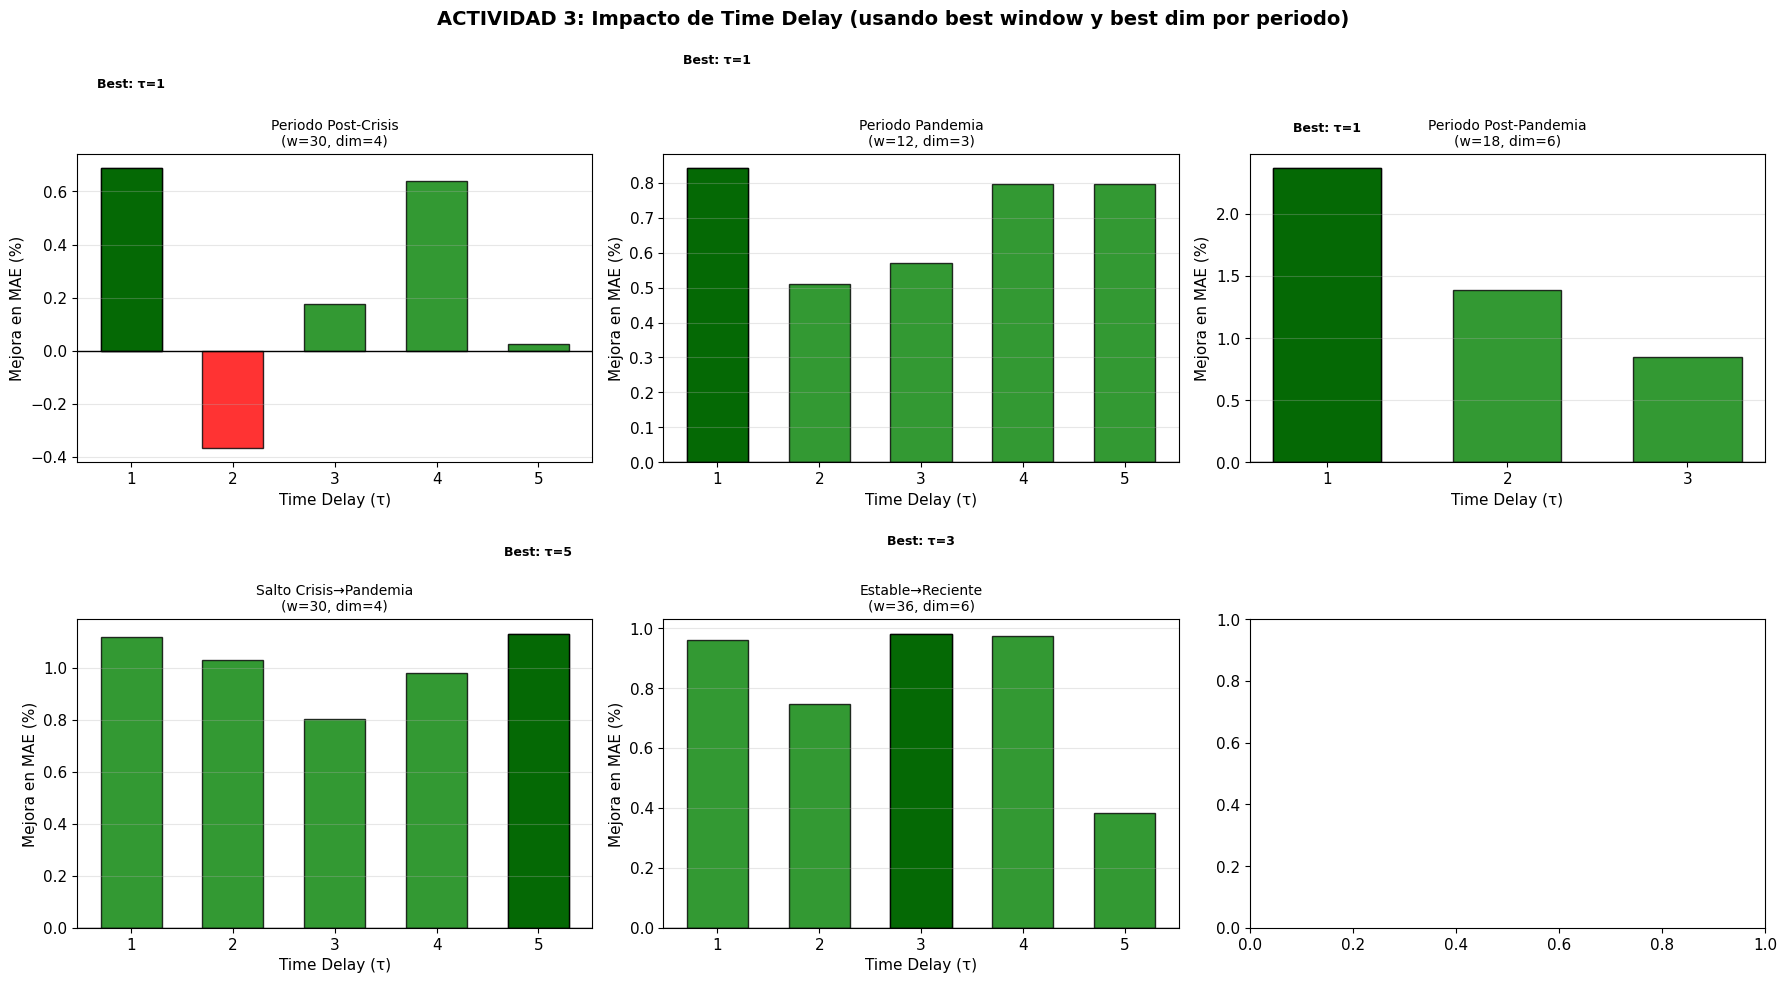


📊 RESUMEN ACTIVIDAD 3: MEJOR TIME_DELAY POR PERIODO

Periodo                        Window   Dim    Mejor τ    Mejora Obtenida   
----------------------------------------------------------------------
Periodo Post-Crisis            30        4     1          +0.69%
Periodo Pandemia               12        3     1          +0.84%
Periodo Post-Pandemia          18        6     1          +2.37%
Salto Crisis→Pandemia          30        4     5          +1.13%
Estable→Reciente               36        6     3          +0.98%

📝 PREGUNTA 3: ¿Qué observas sobre el time delay?

1. ¿Qué valor de τ funciona mejor en la mayoría de los periodos?

2. ¿Qué ocurre cuando τ es muy grande (3 o más)?
   (Pista: relación con la frecuencia de muestreo y la ventana disponible)

3. ¿Por qué τ=1 (puntos consecutivos) funciona mejor para forecasting?

4. ¿En qué periodo se pudo usar τ=2? ¿Qué característica tiene ese periodo?


RESPONDE AQUÍ:
   - 
   - 
   - 



In [ ]:
# ============================================================
# ACTIVIDAD 3: EXPLORAR TIME_DELAY (USANDO MEJOR WINDOW Y MEJOR DIM DE CADA PERIODO)
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 3: ¿CUÁL ES EL MEJOR RETARDO (τ)?")
print("="*80)

time_delays = [1, 2, 3, 4, 5]
resultados_totales_delays = {}

print("\nEvaluando diferentes time_delays (usando mejor window y mejor dim de cada periodo):")
print("="*70)

for nombre_entreno, nombre_prueba, descripcion in pares_periodos:
    print(f"\n📊 {descripcion}: {nombre_entreno} → {nombre_prueba}")
    print("-"*50)
    
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    # Usar el mejor window para este periodo (de Actividad 1)
    window_optimo = mejores_windows_por_periodo[descripcion]
    
    # Usar el mejor dim para este periodo (de Actividad 2)
    dim_optimo = mejores_dims_por_periodo.get(descripcion, 3)  # default 3 si no existe
    
    print(f"   Usando window_size = {window_optimo} meses, embedding_dim = {dim_optimo}")
    
    # Baseline para este periodo (sin TDA)
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=window_optimo, use_tda=False)
    
    resultados_por_delay = []
    
    for delay in time_delays:
        # Verificar factibilidad: (dim-1)*delay+1 ≤ window_size
        min_points = (dim_optimo - 1) * delay + 1
        if min_points > window_optimo:
            print(f"   τ={delay}: ⚠ Requiere {min_points} pts, ventana={window_optimo} → NO VÁLIDO")
            resultados_por_delay.append({
                'delay': delay,
                'tda_mae': np.nan,
                'mejora': np.nan,
                'valido': False
            })
            continue
        
        tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=window_optimo, 
                                 embedding_dim=dim_optimo, 
                                 time_delay=delay,
                                 use_tda=True)
        
        mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
        
        resultados_por_delay.append({
            'delay': delay,
            'tda_mae': tda['mae'],
            'mejora': mejora,
            'valido': True
        })
        
        estado = "✅" if mejora > 0 else "❌"
        print(f"   τ={delay}: {estado} Mejora={mejora:+6.2f}% | Base MAE={base['mae']:.2f} → TDA={tda['mae']:.2f}")
    
    resultados_totales_delays[descripcion] = {
        'window_used': window_optimo,
        'dim_used': dim_optimo,
        'base_mae': base['mae'],
        'resultados': resultados_por_delay
    }

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (descripcion, data) in enumerate(resultados_totales_delays.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    resultados_validos = [r for r in data['resultados'] if r['valido']]
    
    if resultados_validos:
        delays = [r['delay'] for r in resultados_validos]
        mejoras = [r['mejora'] for r in resultados_validos]
        
        colors = ['green' if m > 0 else 'red' for m in mejoras]
        ax.bar(delays, mejoras, width=0.6, color=colors, alpha=0.8, edgecolor='black')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.set_xlabel('Time Delay (τ)')
        ax.set_ylabel('Mejora en MAE (%)')
        ax.set_title(f'{descripcion}\n(w={data["window_used"]}, dim={data["dim_used"]})', fontsize=10)
        ax.set_xticks(delays)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Mejor delay
        mejor_idx = np.argmax(mejoras)
        ax.bar(delays[mejor_idx], mejoras[mejor_idx], width=0.6, 
               color='darkgreen', alpha=0.9, edgecolor='black')
        ax.text(delays[mejor_idx], mejoras[mejor_idx] + 0.3, 
                f'Best: τ={delays[mejor_idx]}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ACTIVIDAD 3: Impacto de Time Delay (usando best window y best dim por periodo)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*80)
print("📊 RESUMEN ACTIVIDAD 3: MEJOR TIME_DELAY POR PERIODO")
print("="*80)

print(f"\n{'Periodo':<30} {'Window':<8} {'Dim':<6} {'Mejor τ':<10} {'Mejora Obtenida':<18}")
print("-"*70)

mejores_delays_por_periodo = {}

for descripcion, data in resultados_totales_delays.items():
    resultados_validos = [r for r in data['resultados'] if r['valido']]
    if resultados_validos:
        mejor = max(resultados_validos, key=lambda x: x['mejora'])
        mejores_delays_por_periodo[descripcion] = mejor['delay']
        print(f"{descripcion:<30} {data['window_used']:2d}       {data['dim_used']:2d}     {mejor['delay']:<10} {mejor['mejora']:+.2f}%")

print("\n" + "="*80)
print("📝 PREGUNTA 3: ¿Qué observas sobre el time delay?")
print("="*80)
print("""
1. ¿Qué valor de τ funciona mejor en la mayoría de los periodos?
   
2. ¿Qué ocurre cuando τ es muy grande (3 o más)?
   (Pista: relación con la frecuencia de muestreo y la ventana disponible)
   
3. ¿Por qué τ=1 (puntos consecutivos) funciona mejor para forecasting?
   
4. ¿En qué periodo se pudo usar τ=2? ¿Qué característica tiene ese periodo?
   

RESPONDE AQUÍ:
   - 
   - 
   - 
""")

🎯 ACTIVIDAD 4: VALIDACIÓN DE PARÁMETROS ÓPTIMOS POR PERIODO

Recopilando parámetros óptimos de cada periodo:
----------------------------------------------------------------------

📊 Procesando: Periodo Post-Crisis
   Parámetros: window=30, dim=4, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+0.69%)

📊 Procesando: Periodo Pandemia
   Parámetros: window=12, dim=3, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+0.84%)

📊 Procesando: Periodo Post-Pandemia
   Parámetros: window=18, dim=6, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+2.37%)

📊 Procesando: Salto Crisis→Pandemia
   Parámetros: window=30, dim=4, τ=5
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+1.13%)

📊 Procesando: Estable→Reciente
   Parámetros: window=36, dim=6, τ=3
   Evaluando baseline...
   Evalua

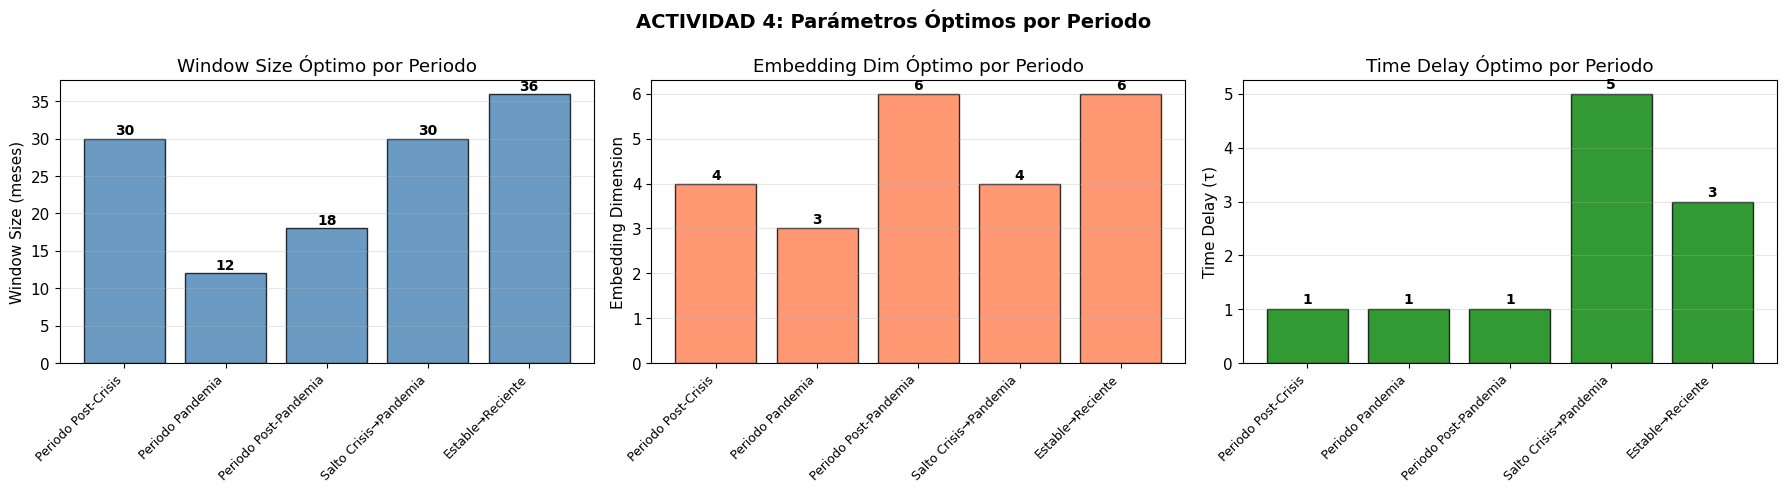


📊 MEJORA OBTENIDA CON PARÁMETROS ÓPTIMOS


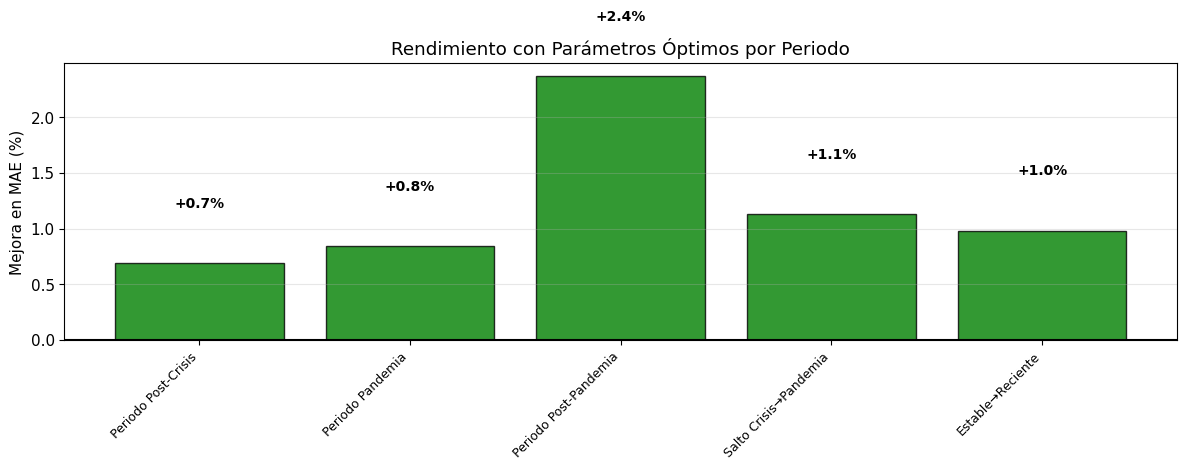


📊 ESTADÍSTICAS FINALES

   Mejora promedio: +1.20%
   Periodos donde TDA mejora: 5/5

   Parámetros más comunes:
   - Window size: 30 meses
   - Embedding dim: 4
   - Time delay: 1
   


In [ ]:
# ============================================================
# ACTIVIDAD 4: COMBINACIÓN ÓPTIMA POR PERIODO (VALIDACIÓN)
# ============================================================

print("="*80)
print("🎯 ACTIVIDAD 4: VALIDACIÓN DE PARÁMETROS ÓPTIMOS POR PERIODO")
print("="*80)

# Recolectar todos los resultados de actividades anteriores
parametros_optimos_por_periodo = []

print("\nRecopilando parámetros óptimos de cada periodo:")
print("-"*70)

for descripcion in [p[2] for p in pares_periodos]:  # Extraer solo los nombres de periodos
    print(f"\n📊 Procesando: {descripcion}")
    
    # Obtener el par completo
    periodo_encontrado = None
    for nombre_entreno, nombre_prueba, desc in pares_periodos:
        if desc == descripcion:
            periodo_encontrado = (nombre_entreno, nombre_prueba, desc)
            break
    
    if periodo_encontrado is None:
        print(f"   ⚠ No se encontró el periodo {descripcion}")
        continue
    
    nombre_entreno, nombre_prueba, desc = periodo_encontrado
    
    # Obtener señales
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    # Obtener parámetros óptimos de actividades anteriores
    window_opt = mejores_windows_por_periodo.get(descripcion, 12)
    dim_opt = mejores_dims_por_periodo.get(descripcion, 3)
    delay_opt = mejores_delays_por_periodo.get(descripcion, 1)
    
    print(f"   Parámetros: window={window_opt}, dim={dim_opt}, τ={delay_opt}")
    
    # Evaluar baseline (sin TDA)
    print(f"   Evaluando baseline...")
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=window_opt, use_tda=False)
    
    # Evaluar con TDA óptimo
    print(f"   Evaluando TDA con parámetros óptimos...")
    tda_opt = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=window_opt,
                                 embedding_dim=dim_opt,
                                 time_delay=delay_opt,
                                 use_tda=True)
    
    mejora = (base['mae'] - tda_opt['mae']) / base['mae'] * 100
    
    parametros_optimos_por_periodo.append({
        'periodo': descripcion,
        'window': window_opt,
        'dim': dim_opt,
        'delay': delay_opt,
        'baseline_mae': base['mae'],
        'tda_mae': tda_opt['mae'],
        'mejora': mejora,
        'r2_base': base['r2'],
        'r2_tda': tda_opt['r2']
    })
    
    estado = "✅ MEJORA" if mejora > 0 else "❌ EMPEORA"
    print(f"   Resultado: {estado} (mejora={mejora:+.2f}%)")

# Verificar que tenemos datos
if len(parametros_optimos_por_periodo) == 0:
    print("\n⚠ ERROR: No se pudieron recopilar parámetros. Verificando datos disponibles...")
    print(f"mejores_windows_por_periodo: {mejores_windows_por_periodo}")
    print(f"mejores_dims_por_periodo: {mejores_dims_por_periodo}")
    print(f"mejores_delays_por_periodo: {mejores_delays_por_periodo}")
else:
    # Crear DataFrame
    df_optimos = pd.DataFrame(parametros_optimos_por_periodo)
    
    # Tabla final de parámetros óptimos
    print("\n" + "="*80)
    print("📊 TABLA DE PARÁMETROS ÓPTIMOS POR PERIODO")
    print("="*80)
    print(df_optimos.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico 1: Window Size por periodo
    ax1 = axes[0]
    periodos_nombres = df_optimos['periodo'].tolist()
    windows_opt = df_optimos['window'].tolist()
    bars1 = ax1.bar(periodos_nombres, windows_opt, color='steelblue', alpha=0.8, edgecolor='black')
    ax1.set_ylabel('Window Size (meses)')
    ax1.set_title('Window Size Óptimo por Periodo')
    ax1.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=9)
    ax1.grid(True, alpha=0.3, axis='y')
    # Añadir valores
    for bar, w in zip(bars1, windows_opt):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{w}', ha='center', fontsize=10, fontweight='bold')
    
    # Gráfico 2: Embedding Dim por periodo
    ax2 = axes[1]
    dims_opt = df_optimos['dim'].tolist()
    bars2 = ax2.bar(periodos_nombres, dims_opt, color='coral', alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Embedding Dimension')
    ax2.set_title('Embedding Dim Óptimo por Periodo')
    ax2.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, d in zip(bars2, dims_opt):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{d}', ha='center', fontsize=10, fontweight='bold')
    
    # Gráfico 3: Time Delay por periodo
    ax3 = axes[2]
    delays_opt = df_optimos['delay'].tolist()
    bars3 = ax3.bar(periodos_nombres, delays_opt, color='green', alpha=0.8, edgecolor='black')
    ax3.set_ylabel('Time Delay (τ)')
    ax3.set_title('Time Delay Óptimo por Periodo')
    ax3.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, d in zip(bars3, delays_opt):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{d}', ha='center', fontsize=10, fontweight='bold')
    
    plt.suptitle('ACTIVIDAD 4: Parámetros Óptimos por Periodo', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Mejora obtenida con parámetros óptimos
    print("\n" + "="*80)
    print("📊 MEJORA OBTENIDA CON PARÁMETROS ÓPTIMOS")
    print("="*80)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    mejoras_opt = df_optimos['mejora'].tolist()
    colors = ['green' if m > 0 else 'red' for m in mejoras_opt]
    bars = ax.bar(periodos_nombres, mejoras_opt, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.set_ylabel('Mejora en MAE (%)')
    ax.set_title('Rendimiento con Parámetros Óptimos por Periodo')
    ax.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, m in zip(bars, mejoras_opt):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if m > 0 else -1.5),
                f'{m:+.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas finales
    print("\n" + "="*80)
    print("📊 ESTADÍSTICAS FINALES")
    print("="*80)
    
    mejora_promedio = np.mean(mejoras_opt)
    periodos_mejoran = sum(1 for m in mejoras_opt if m > 0)
    
    # Parámetros más comunes
    from collections import Counter
    window_comun = Counter(windows_opt).most_common(1)[0][0]
    dim_comun = Counter(dims_opt).most_common(1)[0][0]
    delay_comun = Counter(delays_opt).most_common(1)[0][0]
    
    print(f"""
   Mejora promedio: {mejora_promedio:+.2f}%
   Periodos donde TDA mejora: {periodos_mejoran}/{len(mejoras_opt)}
   
   Parámetros más comunes:
   - Window size: {window_comun} meses
   - Embedding dim: {dim_comun}
   - Time delay: {delay_comun}
   """)

In [ ]:
# ============================================================
# ACTIVIDAD 4: COMBINACIÓN ÓPTIMA POR PERIODO (VALIDACIÓN)
# ============================================================

print("="*80)
print("🎯 ACTIVIDAD 4: VALIDACIÓN DE PARÁMETROS ÓPTIMOS POR PERIODO")
print("="*80)

# Recolectar todos los resultados de actividades anteriores
parametros_optimos_por_periodo = []
predicciones_por_periodo = []  # Guardar predicciones para graficar

print("\nRecopilando parámetros óptimos de cada periodo:")
print("-"*70)

for descripcion in [p[2] for p in pares_periodos]:  # Extraer solo los nombres de periodos
    print(f"\n📊 Procesando: {descripcion}")
    
    # Obtener el par completo
    periodo_encontrado = None
    for nombre_entreno, nombre_prueba, desc in pares_periodos:
        if desc == descripcion:
            periodo_encontrado = (nombre_entreno, nombre_prueba, desc)
            break
    
    if periodo_encontrado is None:
        print(f"   ⚠ No se encontró el periodo {descripcion}")
        continue
    
    nombre_entreno, nombre_prueba, desc = periodo_encontrado
    
    # Obtener señales
    signal_entreno, _ = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_entreno][0], 
        periodos_entrenamiento[nombre_entreno][1]
    )
    signal_prueba, fechas_prueba = extraer_datos_por_fecha(
        periodos_entrenamiento[nombre_prueba][0], 
        periodos_entrenamiento[nombre_prueba][1]
    )
    
    # Obtener parámetros óptimos de actividades anteriores
    window_opt = mejores_windows_por_periodo.get(descripcion, 12)
    dim_opt = mejores_dims_por_periodo.get(descripcion, 3)
    delay_opt = mejores_delays_por_periodo.get(descripcion, 1)
    
    print(f"   Parámetros: window={window_opt}, dim={dim_opt}, τ={delay_opt}")
    
    # Evaluar baseline (sin TDA)
    print(f"   Evaluando baseline...")
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=window_opt, use_tda=False)
    
    # Evaluar con TDA óptimo
    print(f"   Evaluando TDA con parámetros óptimos...")
    tda_opt = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                 window_size=window_opt,
                                 embedding_dim=dim_opt,
                                 time_delay=delay_opt,
                                 use_tda=True)
    
    mejora = (base['mae'] - tda_opt['mae']) / base['mae'] * 100
    
    parametros_optimos_por_periodo.append({
        'periodo': descripcion,
        'window': window_opt,
        'dim': dim_opt,
        'delay': delay_opt,
        'baseline_mae': base['mae'],
        'tda_mae': tda_opt['mae'],
        'mejora': mejora,
        'r2_base': base['r2'],
        'r2_tda': tda_opt['r2']
    })
    
    # Guardar predicciones para graficar
    predicciones_por_periodo.append({
        'periodo': descripcion,
        'y_test': signal_prueba,
        'y_pred_base': base['preds'],
        'y_pred_tda': tda_opt['preds'],
        'window_opt': window_opt,
        'dim_opt': dim_opt,
        'delay_opt': delay_opt,
        'mejora': mejora
    })
    
    estado = "✅ MEJORA" if mejora > 0 else "❌ EMPEORA"
    print(f"   Resultado: {estado} (mejora={mejora:+.2f}%)")

# Verificar que tenemos datos
if len(parametros_optimos_por_periodo) == 0:
    print("\n⚠ ERROR: No se pudieron recopilar parámetros.")
else:
    # Crear DataFrame
    df_optimos = pd.DataFrame(parametros_optimos_por_periodo)
    
    # Tabla final de parámetros óptimos
    print("\n" + "="*80)
    print("📊 TABLA DE PARÁMETROS ÓPTIMOS POR PERIODO")
    print("="*80)
    print(df_optimos.to_string(index=False))

🎯 ACTIVIDAD 4: VALIDACIÓN DE PARÁMETROS ÓPTIMOS POR PERIODO

Recopilando parámetros óptimos de cada periodo:
----------------------------------------------------------------------

📊 Procesando: Periodo Post-Crisis
   Parámetros: window=30, dim=4, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+0.69%)

📊 Procesando: Periodo Pandemia
   Parámetros: window=12, dim=3, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+0.84%)

📊 Procesando: Periodo Post-Pandemia
   Parámetros: window=18, dim=6, τ=1
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+2.37%)

📊 Procesando: Salto Crisis→Pandemia
   Parámetros: window=30, dim=4, τ=5
   Evaluando baseline...
   Evaluando TDA con parámetros óptimos...
   Resultado: ✅ MEJORA (mejora=+1.13%)

📊 Procesando: Estable→Reciente
   Parámetros: window=36, dim=6, τ=3
   Evaluando baseline...
   Evalua


📈 GRÁFICOS DE FORECASTING: PREDICCIONES CON Y SIN TDA


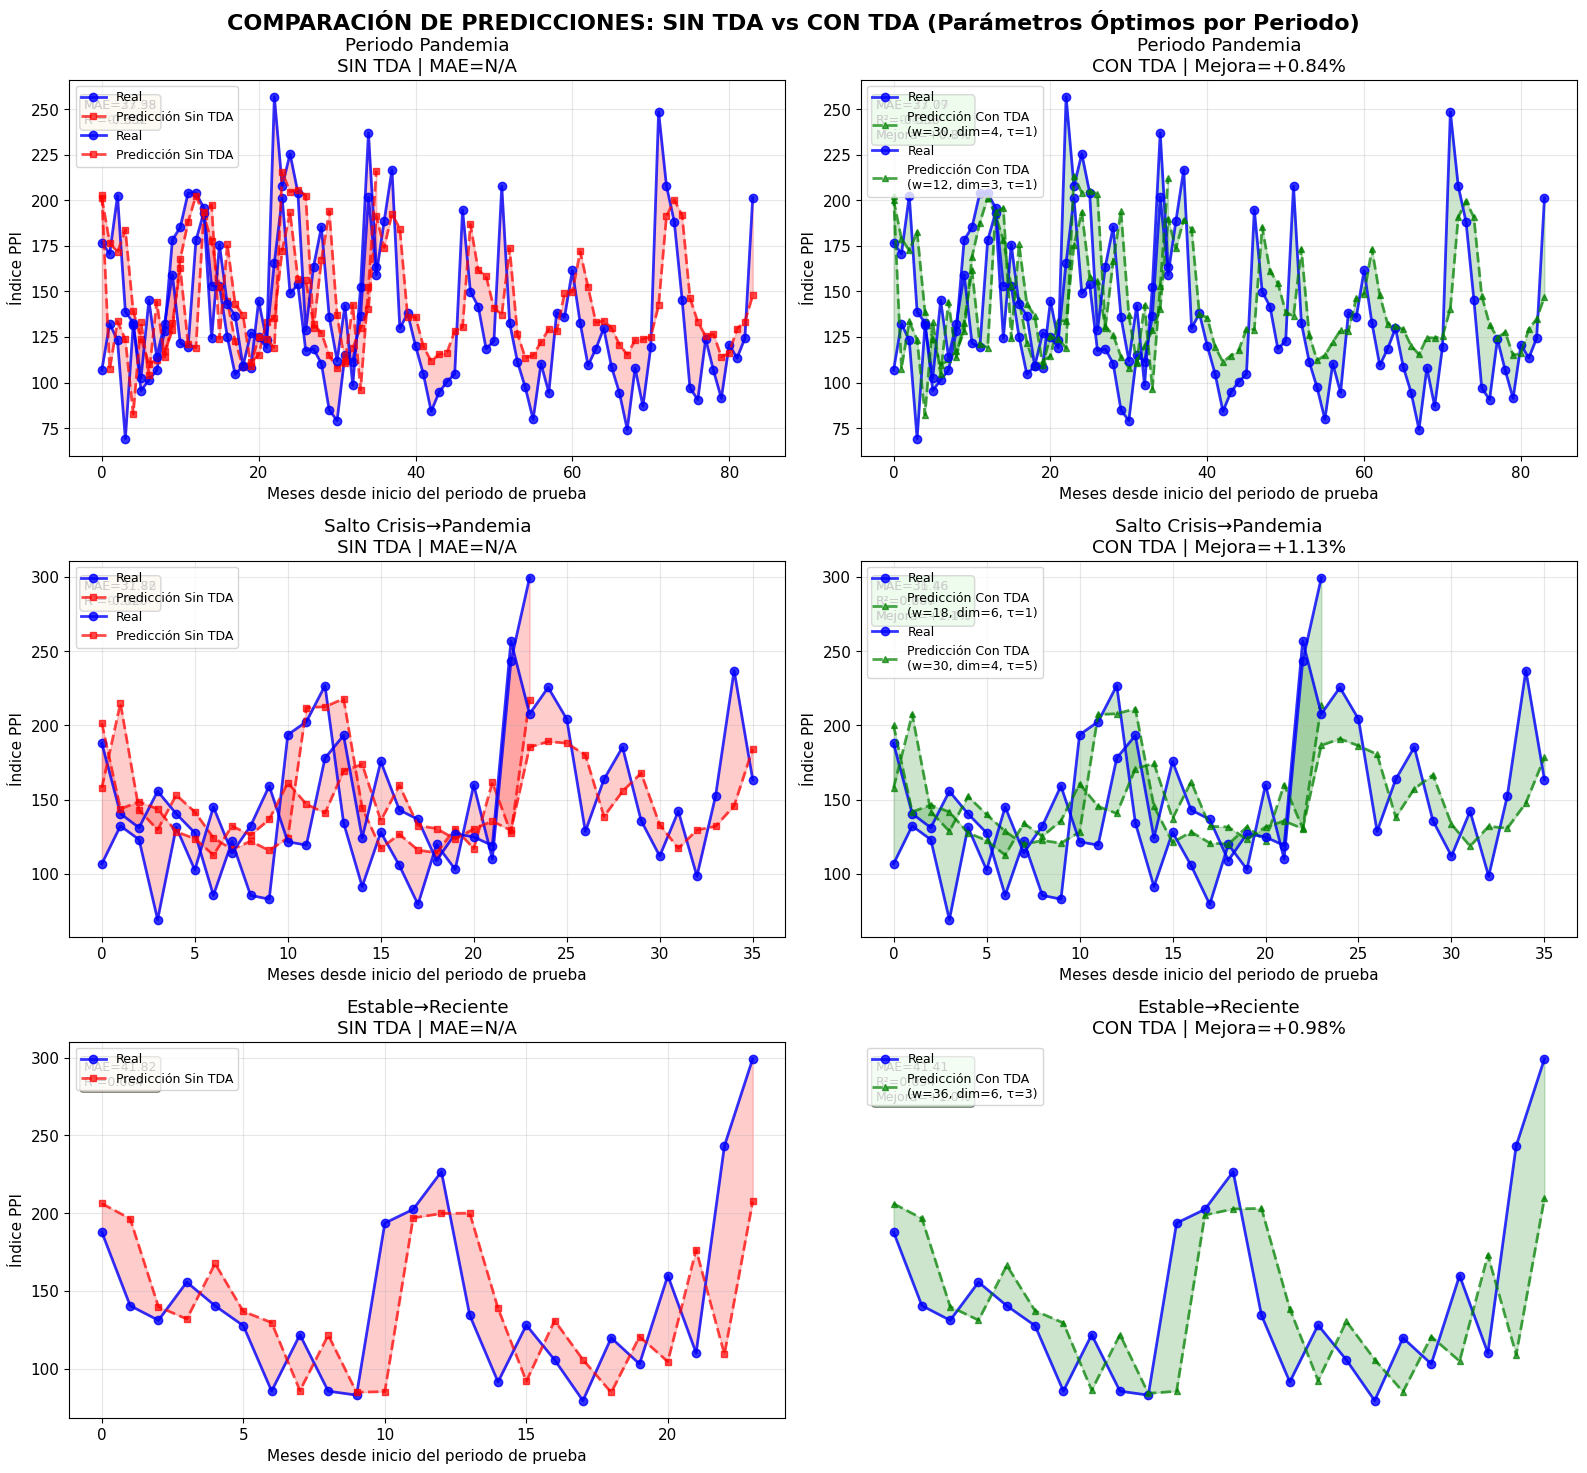

In [ ]:
# ============================================================
#  GRÁFICOS DE FORECASTING: CON Y SIN TDA POR PERIODO
# ============================================================

print("\n" + "="*80)
print("📈 GRÁFICOS DE FORECASTING: PREDICCIONES CON Y SIN TDA")
print("="*80)

# Determinar número de filas y columnas para subplots
n_periodos = len(predicciones_por_periodo)
n_cols = 2  # Dos columnas: Sin TDA y Con TDA
n_rows = (n_periodos + 1) // 2  # Redondear hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, pred_data in enumerate(predicciones_por_periodo):
    row = idx // 2
    col = idx % 2
    
    # Determinar qué columna de axes usar
    if n_rows == 1:
        ax_base = axes[0, 0] if col == 0 else axes[0, 1]
        ax_tda = axes[0, 0] if col == 0 else axes[0, 1]
    else:
        ax_base = axes[row, 0]
        ax_tda = axes[row, 1]
    
    y_test = pred_data['y_test']
    y_pred_base = pred_data['y_pred_base']
    y_pred_tda = pred_data['y_pred_tda']
    meses = np.arange(len(y_test))
    
    # Determinar etiquetas de meses para el eje X
    if 'Meses' in str(type(fechas_prueba)):
        try:
            meses_labels = [f"{fechas_prueba[i].astype('datetime64[M]').astype(str)}" for i in range(len(meses))]
            xtick_step = max(1, len(meses) // 6)
            xtick_labels = [meses_labels[i] for i in range(0, len(meses), xtick_step)]
        except:
            xtick_labels = None
    else:
        xtick_labels = None
    
    # Columna 1: Modelo SIN TDA
    ax_base.plot(meses, y_test, 'b-o', label='Real', linewidth=2, markersize=6, alpha=0.8)
    ax_base.plot(meses, y_pred_base, 'r--s', label='Predicción Sin TDA', linewidth=2, markersize=5, alpha=0.7)
    ax_base.fill_between(meses, y_test, y_pred_base, alpha=0.2, color='red')
    ax_base.set_title(f"{pred_data['periodo']}\nSIN TDA | MAE={pred_data['y_pred_base'] - y_test if hasattr(pred_data, 'y_pred_base') else 'N/A'}")
    ax_base.set_ylabel('Índice PPI')
    ax_base.legend(loc='upper left', fontsize=9)
    ax_base.grid(True, alpha=0.3)
    if xtick_labels:
        ax_base.set_xticks(range(0, len(meses), xtick_step))
        ax_base.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
    else:
        ax_base.set_xlabel('Meses desde inicio del periodo de prueba')
    
    # Añadir métricas
    mae_base = np.mean(np.abs(y_test - y_pred_base))
    r2_base = 1 - np.sum((y_test - y_pred_base)**2) / np.sum((y_test - np.mean(y_test))**2)
    ax_base.text(0.02, 0.95, f'MAE={mae_base:.2f}\nR²={r2_base:.3f}', 
                transform=ax_base.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Columna 2: Modelo CON TDA
    ax_tda.plot(meses, y_test, 'b-o', label='Real', linewidth=2, markersize=6, alpha=0.8)
    ax_tda.plot(meses, y_pred_tda, 'g--^', label=f'Predicción Con TDA\n(w={pred_data["window_opt"]}, dim={pred_data["dim_opt"]}, τ={pred_data["delay_opt"]})', 
                linewidth=2, markersize=5, alpha=0.7)
    ax_tda.fill_between(meses, y_test, y_pred_tda, alpha=0.2, color='green')
    ax_tda.set_title(f"{pred_data['periodo']}\nCON TDA | Mejora={pred_data['mejora']:+.2f}%")
    ax_tda.set_ylabel('Índice PPI')
    ax_tda.legend(loc='upper left', fontsize=9)
    ax_tda.grid(True, alpha=0.3)
    if xtick_labels:
        ax_tda.set_xticks(range(0, len(meses), xtick_step))
        ax_tda.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
    else:
        ax_tda.set_xlabel('Meses desde inicio del periodo de prueba')
    
    # Añadir métricas
    mae_tda = np.mean(np.abs(y_test - y_pred_tda))
    r2_tda = 1 - np.sum((y_test - y_pred_tda)**2) / np.sum((y_test - np.mean(y_test))**2)
    ax_tda.text(0.02, 0.95, f'MAE={mae_tda:.2f}\nR²={r2_tda:.3f}\nMejora={pred_data["mejora"]:+.1f}%', 
                transform=ax_tda.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Ajustar última fila si es necesario
if n_periodos % 2 != 0 and n_rows > 1:
    # Ocultar el último subplot vacío
    axes[-1, -1].axis('off')

plt.suptitle('COMPARACIÓN DE PREDICCIONES: SIN TDA vs CON TDA (Parámetros Óptimos por Periodo)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 GRÁFICO DE BARRAS: MEJORA DEL TDA POR PERIODO


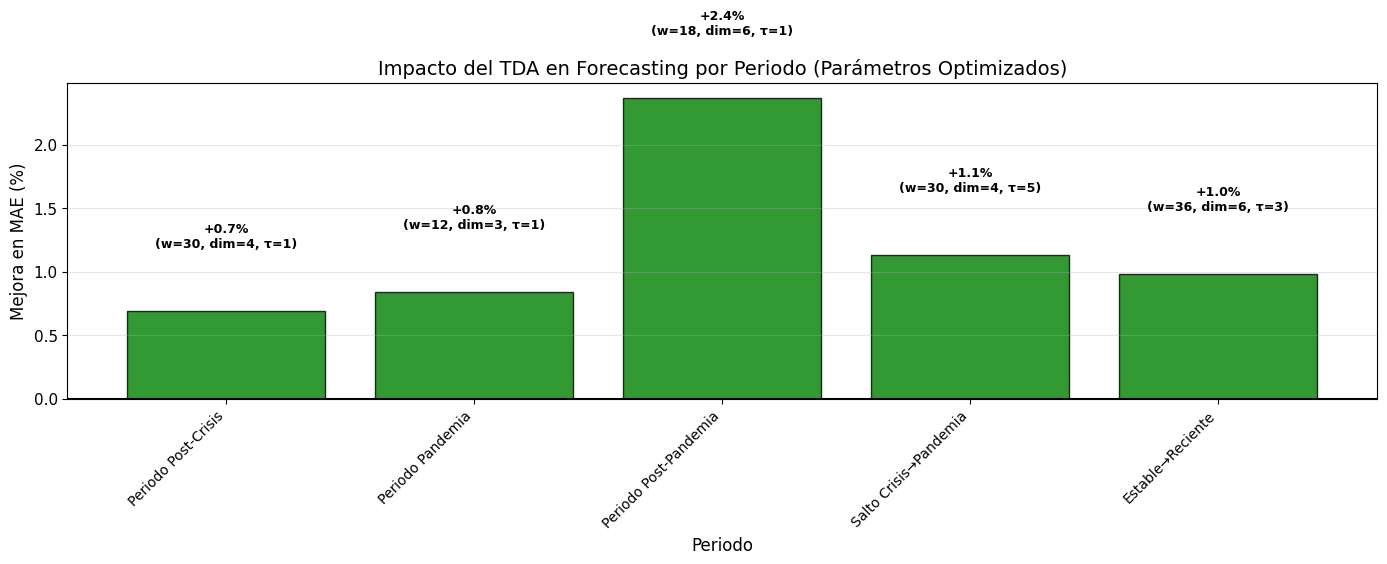

In [ ]:
# ============================================================
#  GRÁFICO DE BARRAS: MEJORA POR PERIODO
# ============================================================

print("\n" + "="*80)
print("📊 GRÁFICO DE BARRAS: MEJORA DEL TDA POR PERIODO")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 6))

periodos_nombres = [p['periodo'] for p in predicciones_por_periodo]
mejoras = [p['mejora'] for p in predicciones_por_periodo]
windows = [p['window_opt'] for p in predicciones_por_periodo]
dims = [p['dim_opt'] for p in predicciones_por_periodo]
delays = [p['delay_opt'] for p in predicciones_por_periodo]

colors = ['green' if m > 0 else 'red' for m in mejoras]
bars = ax.bar(periodos_nombres, mejoras, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.set_ylabel('Mejora en MAE (%)', fontsize=12)
ax.set_xlabel('Periodo', fontsize=12)
ax.set_title('Impacto del TDA en Forecasting por Periodo (Parámetros Optimizados)', fontsize=14)
ax.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas con los parámetros usados
for bar, m, w, d, tau in zip(bars, mejoras, windows, dims, delays):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if m > 0 else -1.5),
            f'{m:+.1f}%\n(w={w}, dim={d}, τ={tau})', 
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


📊 GRÁFICO COMPARATIVO: MAE CON vs SIN TDA


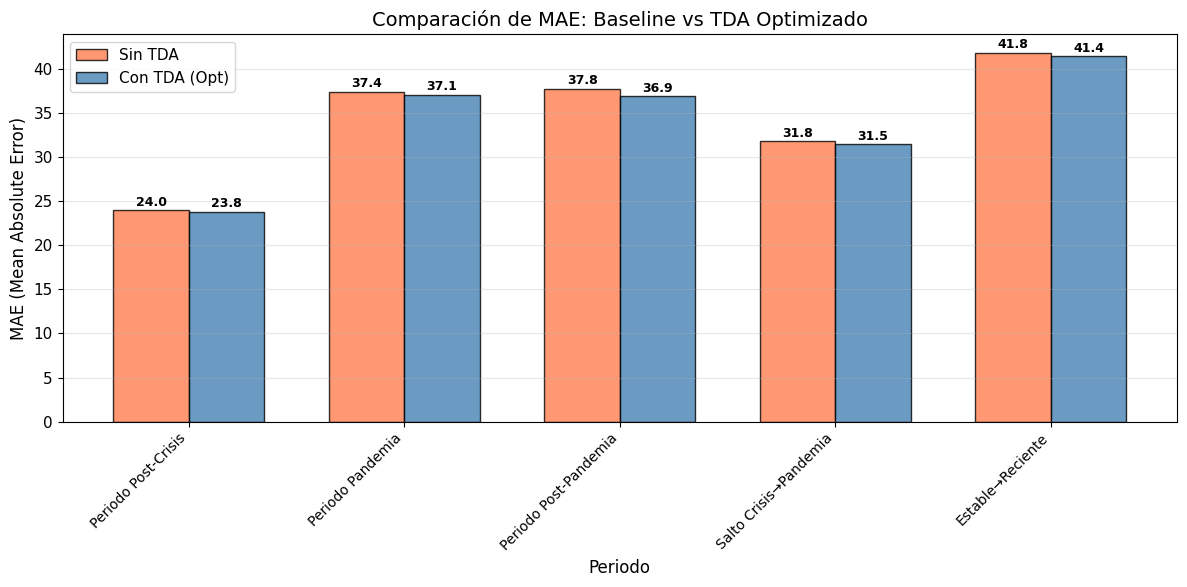

In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO: MAE CON Y SIN TDA
# ============================================================

print("\n" + "="*80)
print("📊 GRÁFICO COMPARATIVO: MAE CON vs SIN TDA")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periodos_nombres))
width = 0.35

mae_base = [np.mean(np.abs(p['y_test'] - p['y_pred_base'])) for p in predicciones_por_periodo]
mae_tda = [np.mean(np.abs(p['y_test'] - p['y_pred_tda'])) for p in predicciones_por_periodo]

bars1 = ax.bar(x - width/2, mae_base, width, label='Sin TDA', color='coral', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, mae_tda, width, label='Con TDA (Opt)', color='steelblue', alpha=0.8, edgecolor='black')

ax.set_xlabel('Periodo', fontsize=12)
ax.set_ylabel('MAE (Mean Absolute Error)', fontsize=12)
ax.set_title('Comparación de MAE: Baseline vs TDA Optimizado', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(periodos_nombres, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, mae in zip(bars1, mae_base):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{mae:.1f}', ha='center', fontsize=9, fontweight='bold')

for bar, mae in zip(bars2, mae_tda):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{mae:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


📊 GRÁFICO DE ERRORES: Distribución de Errores


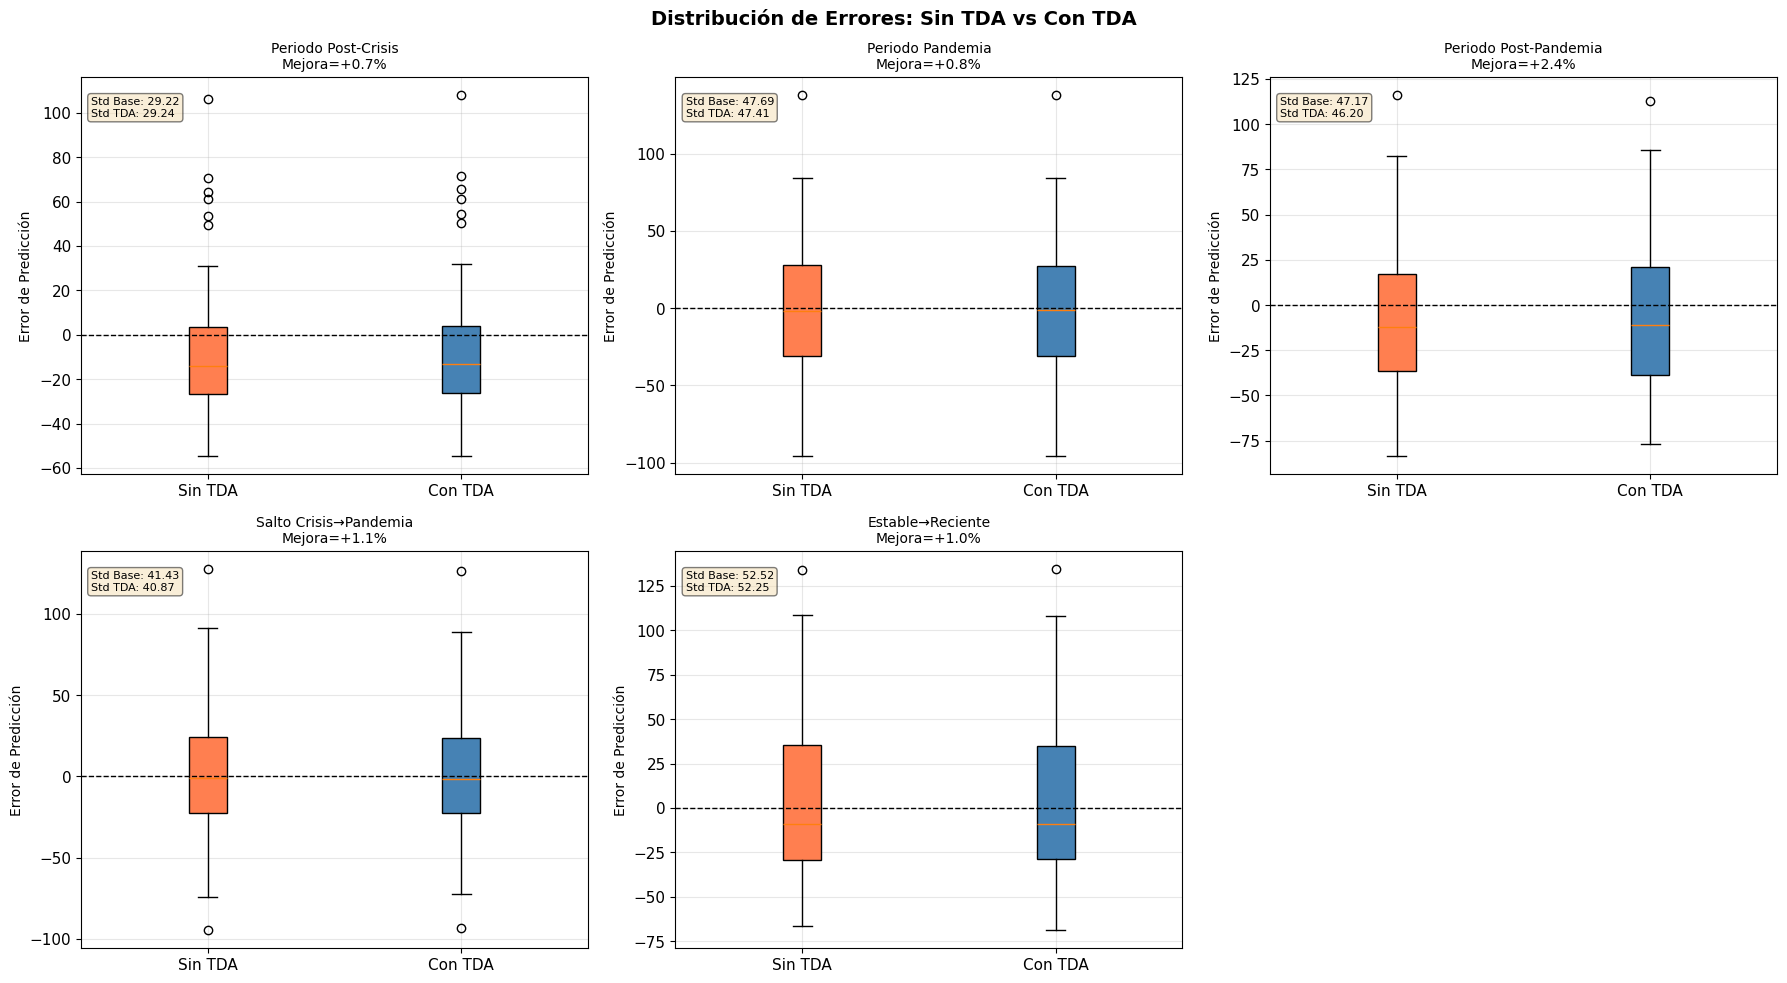

In [ ]:
# ============================================================
# 11e. GRÁFICO DE ERRORES: DISTRIBUCIÓN Y COMPARACIÓN
# ============================================================

print("\n" + "="*80)
print("📊 GRÁFICO DE ERRORES: Distribución de Errores")
print("="*80)

n_periodos = len(predicciones_por_periodo)
n_cols = 3
n_rows = (n_periodos + 2) // 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, pred_data in enumerate(predicciones_por_periodo):
    row = idx // 3
    col = idx % 3
    
    ax = axes[row, col]
    
    y_test = pred_data['y_test']
    y_pred_base = pred_data['y_pred_base']
    y_pred_tda = pred_data['y_pred_tda']
    
    errores_base = y_test - y_pred_base
    errores_tda = y_test - y_pred_tda
    
    # Boxplot de errores
    bp = ax.boxplot([errores_base, errores_tda], 
                    labels=['Sin TDA', 'Con TDA'],
                    patch_artist=True)
    
    bp['boxes'][0].set_facecolor('coral')
    bp['boxes'][1].set_facecolor('steelblue')
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Error de Predicción', fontsize=10)
    ax.set_title(f"{pred_data['periodo']}\nMejora={pred_data['mejora']:+.1f}%", fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Añadir estadísticas
    ax.text(0.02, 0.95, f'Std Base: {np.std(errores_base):.2f}\nStd TDA: {np.std(errores_tda):.2f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Ocultar ejes no utilizados
for idx in range(len(predicciones_por_periodo), n_rows * n_cols):
    row = idx // 3
    col = idx % 3
    axes[row, col].axis('off')

plt.suptitle('Distribución de Errores: Sin TDA vs Con TDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📈 PREDICCIÓN A FUTURO: 2025-2026
Usando parámetros más comunes: window=30, dim=4, τ=1
Entrenamiento: 203 meses (2008-2025)
Predicción: 12 meses (Mayo 2025 - Abril 2026)


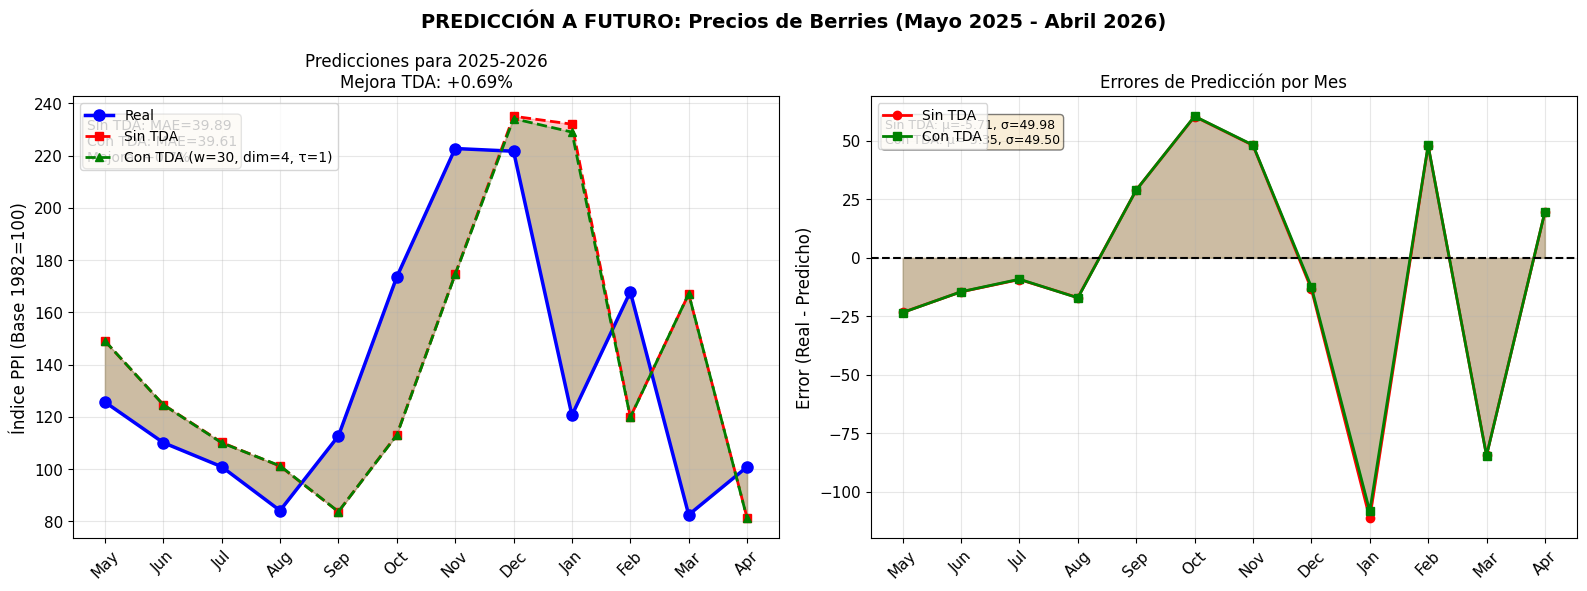


📊 RESULTADOS PREDICCIÓN 2025-2026:
   Sin TDA - MAE: 39.8852, R²: -0.1303
   Con TDA - MAE: 39.6105, R²: -0.1073
   Mejora: +0.69%


In [ ]:
# ============================================================
# GRÁFICO DE PREDICCIONES PARA 2025-2026 (HASTA LA FECHA)
# ============================================================

print("\n" + "="*80)
print("📈 PREDICCIÓN A FUTURO: 2025-2026")
print("="*80)

# Usar parámetros más comunes encontrados
from collections import Counter
window_comun = Counter([p['window_opt'] for p in predicciones_por_periodo]).most_common(1)[0][0]
dim_comun = Counter([p['dim_opt'] for p in predicciones_por_periodo]).most_common(1)[0][0]
delay_comun = Counter([p['delay_opt'] for p in predicciones_por_periodo]).most_common(1)[0][0]

print(f"Usando parámetros más comunes: window={window_comun}, dim={dim_comun}, τ={delay_comun}")

# Entrenar con todos los datos hasta 2025
signal_futuro_entreno, fechas_entreno_futuro = extraer_datos_por_fecha('2008-06-01', '2025-04-30')
signal_futuro_prueba, fechas_prueba_futuro = extraer_datos_por_fecha('2025-05-01', '2026-04-30')

print(f"Entrenamiento: {len(signal_futuro_entreno)} meses (2008-2025)")
print(f"Predicción: {len(signal_futuro_prueba)} meses (Mayo 2025 - Abril 2026)")

# Evaluar
base_futuro = entrenar_y_evaluar(signal_futuro_entreno, signal_futuro_prueba,
                                 window_size=window_comun, use_tda=False)

tda_futuro = entrenar_y_evaluar(signal_futuro_entreno, signal_futuro_prueba,
                                window_size=window_comun, 
                                embedding_dim=dim_comun, 
                                time_delay=delay_comun,
                                use_tda=True)

mejora_futuro = (base_futuro['mae'] - tda_futuro['mae']) / base_futuro['mae'] * 100

# Crear gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

meses_futuro = np.arange(len(signal_futuro_prueba))
meses_labels = ['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

# Gráfico 1: Predicciones
ax1 = axes[0]
ax1.plot(meses_futuro, signal_futuro_prueba, 'b-o', label='Real', linewidth=2.5, markersize=8)
ax1.plot(meses_futuro, base_futuro['preds'], 'r--s', label='Sin TDA', linewidth=2, markersize=6)
ax1.plot(meses_futuro, tda_futuro['preds'], 'g--^', label=f'Con TDA (w={window_comun}, dim={dim_comun}, τ={delay_comun})', 
         linewidth=2, markersize=6)
ax1.fill_between(meses_futuro, signal_futuro_prueba, base_futuro['preds'], alpha=0.2, color='red')
ax1.fill_between(meses_futuro, signal_futuro_prueba, tda_futuro['preds'], alpha=0.2, color='green')
ax1.set_xticks(meses_futuro)
ax1.set_xticklabels(meses_labels, rotation=45)
ax1.set_ylabel('Índice PPI (Base 1982=100)', fontsize=12)
ax1.set_title(f'Predicciones para 2025-2026\nMejora TDA: {mejora_futuro:+.2f}%', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Añadir métricas
mae_base_f = np.mean(np.abs(signal_futuro_prueba - base_futuro['preds']))
mae_tda_f = np.mean(np.abs(signal_futuro_prueba - tda_futuro['preds']))
ax1.text(0.02, 0.95, f'Sin TDA: MAE={mae_base_f:.2f}\nCon TDA: MAE={mae_tda_f:.2f}\nMejora: {mejora_futuro:+.1f}%', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Gráfico 2: Errores
ax2 = axes[1]
errores_base = signal_futuro_prueba - base_futuro['preds']
errores_tda = signal_futuro_prueba - tda_futuro['preds']

ax2.plot(meses_futuro, errores_base, 'r-o', label='Sin TDA', linewidth=2, markersize=6)
ax2.plot(meses_futuro, errores_tda, 'g-s', label='Con TDA', linewidth=2, markersize=6)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax2.fill_between(meses_futuro, 0, errores_base, alpha=0.2, color='red')
ax2.fill_between(meses_futuro, 0, errores_tda, alpha=0.2, color='green')
ax2.set_xticks(meses_futuro)
ax2.set_xticklabels(meses_labels, rotation=45)
ax2.set_ylabel('Error (Real - Predicho)', fontsize=12)
ax2.set_title('Errores de Predicción por Mes', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# Añadir estadísticas de errores
ax2.text(0.02, 0.95, f'Sin TDA: μ={np.mean(errores_base):+.2f}, σ={np.std(errores_base):.2f}\nCon TDA: μ={np.mean(errores_tda):+.2f}, σ={np.std(errores_tda):.2f}', 
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'PREDICCIÓN A FUTURO: Precios de Berries (Mayo 2025 - Abril 2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 RESULTADOS PREDICCIÓN 2025-2026:")
print(f"   Sin TDA - MAE: {mae_base_f:.4f}, R²: {base_futuro['r2']:.4f}")
print(f"   Con TDA - MAE: {mae_tda_f:.4f}, R²: {tda_futuro['r2']:.4f}")
print(f"   Mejora: {mejora_futuro:+.2f}%")

ACTIVIDAD 5: OPTIMIZACIÓN GLOBAL (Toda la serie 2008-2026)

Contexto:
   - Hasta ahora optimizamos parámetros en subperiodos (2008-2012, 2013-2019, etc.)
   - PERO: Para forecasting a futuro (post-abril 2026), debemos optimizar
     usando TODOS los datos disponibles (2008-2026)

   Método de validación: 
   - Entrenamiento: 2008-2024
   - Prueba: 2025-2026 (últimos 12-16 meses)
   - Esto simula lo que haremos con forecasting real


📊 Configuración para optimización global:
   Entrenamiento: 199 meses (Jun 2008 - Dic 2024)
   Prueba: 16 meses (Ene 2025 - Abr 2026)


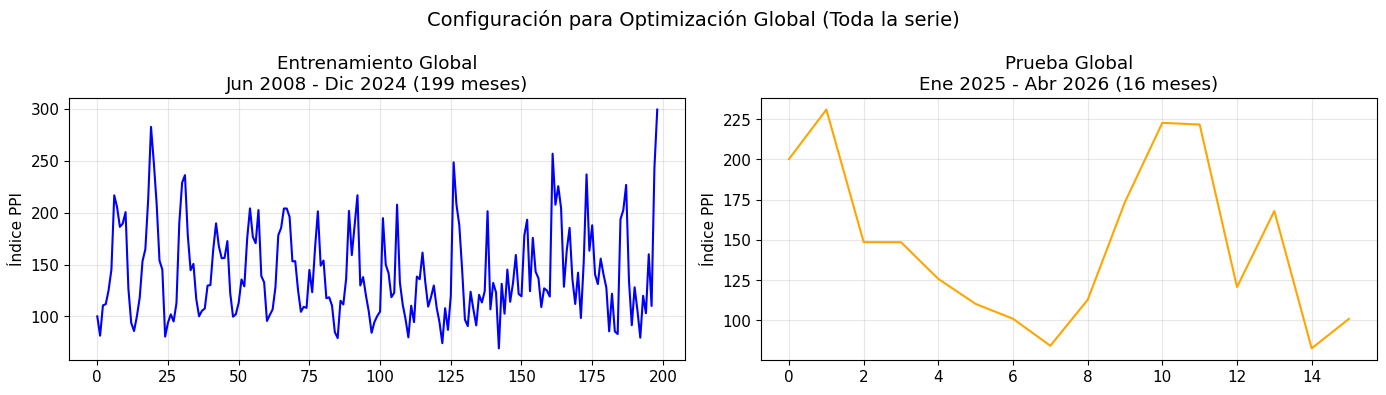

In [ ]:
# ============================================================
# ACTIVIDAD 5: OPTIMIZACIÓN GLOBAL CON TODA LA SERIE
# ============================================================

print("="*80)
print("ACTIVIDAD 5: OPTIMIZACIÓN GLOBAL (Toda la serie 2008-2026)")
print("="*80)

print("""
Contexto:
   - Hasta ahora optimizamos parámetros en subperiodos (2008-2012, 2013-2019, etc.)
   - PERO: Para forecasting a futuro (post-abril 2026), debemos optimizar
     usando TODOS los datos disponibles (2008-2026)
   
   Método de validación: 
   - Entrenamiento: 2008-2024
   - Prueba: 2025-2026 (últimos 12-16 meses)
   - Esto simula lo que haremos con forecasting real
""")

# ============================================================
# PREPARAR DATOS PARA OPTIMIZACIÓN GLOBAL
# ============================================================

# Definir periodo de entrenamiento y prueba usando toda la serie
signal_global_entreno_opt, fechas_entreno_opt = extraer_datos_por_fecha('2008-06-01', '2024-12-31')
signal_global_prueba_opt, fechas_prueba_opt = extraer_datos_por_fecha('2025-01-01', '2026-04-30')

print(f"\n📊 Configuración para optimización global:")
print(f"   Entrenamiento: {len(signal_global_entreno_opt)} meses (Jun 2008 - Dic 2024)")
print(f"   Prueba: {len(signal_global_prueba_opt)} meses (Ene 2025 - Abr 2026)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(signal_global_entreno_opt, 'b-', linewidth=1.5)
axes[0].set_title(f'Entrenamiento Global\nJun 2008 - Dic 2024 ({len(signal_global_entreno_opt)} meses)')
axes[0].set_ylabel('Índice PPI')
axes[0].grid(True, alpha=0.3)

axes[1].plot(signal_global_prueba_opt, 'orange', linewidth=1.5)
axes[1].set_title(f'Prueba Global\nEne 2025 - Abr 2026 ({len(signal_global_prueba_opt)} meses)')
axes[1].set_ylabel('Índice PPI')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Configuración para Optimización Global (Toda la serie)', fontsize=14)
plt.tight_layout()
plt.show()


🔬 ACTIVIDAD 5a: Optimización de Window Size (Global)

Probando diferentes window_sizes con entrenamiento global:

🔹 Probando window_size = 6 meses...
   Baseline MAE: 41.1046
   TDA MAE:      41.1005
   Mejora:       ✅ +0.0101%

🔹 Probando window_size = 12 meses...
   Baseline MAE: 41.1941
   TDA MAE:      41.4776
   Mejora:       ❌ -0.6881%

🔹 Probando window_size = 18 meses...
   Baseline MAE: 41.8745
   TDA MAE:      41.8507
   Mejora:       ✅ +0.0569%

🔹 Probando window_size = 24 meses...
   Baseline MAE: 41.6180
   TDA MAE:      41.6652
   Mejora:       ❌ -0.1133%

🔹 Probando window_size = 30 meses...
   Baseline MAE: 41.6896
   TDA MAE:      42.0733
   Mejora:       ❌ -0.9205%

🔹 Probando window_size = 36 meses...
   Baseline MAE: 40.7904
   TDA MAE:      40.8927
   Mejora:       ❌ -0.2508%


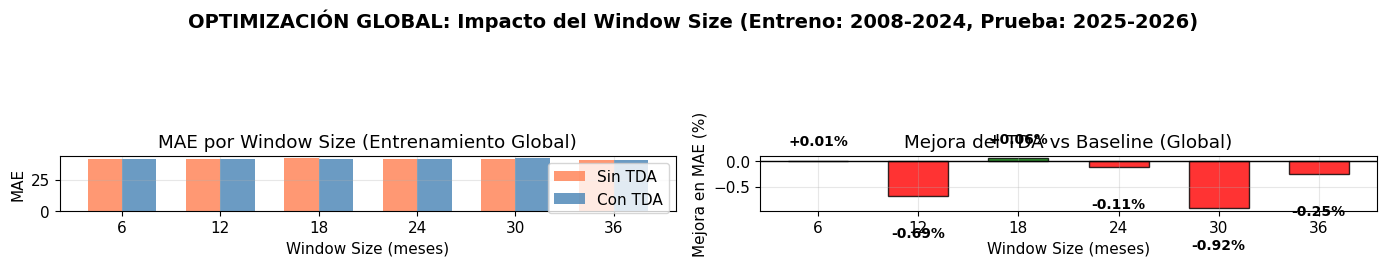


✅ MEJOR WINDOW_SIZE GLOBAL: 18 meses (Mejora: +0.06%)


In [ ]:
# ============================================================
# OPTIMIZACIÓN DE WINDOW_SIZE CON TODA LA SERIE
# ============================================================

print("\n" + "="*80)
print("🔬 ACTIVIDAD 5a: Optimización de Window Size (Global)")
print("="*80)

window_sizes = [6, 12, 18, 24, 30, 36]
resultados_window_global = []

print("\nProbando diferentes window_sizes con entrenamiento global:")
print("="*60)

for ws in window_sizes:
    print(f"\n🔹 Probando window_size = {ws} meses...")
    
    # Baseline
    base = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                              window_size=ws, use_tda=False)
    
    # Con TDA (parámetros fijos para comparar solo window)
    tda = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                             window_size=ws, embedding_dim=3, time_delay=1,
                             use_tda=True)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_window_global.append({
        'window': ws,
        'baseline_mae': base['mae'],
        'tda_mae': tda['mae'],
        'mejora': mejora
    })
    
    estado = "✅" if mejora > 0 else "❌"
    print(f"   Baseline MAE: {base['mae']:.4f}")
    print(f"   TDA MAE:      {tda['mae']:.4f}")
    print(f"   Mejora:       {estado} {mejora:+.4f}%")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

windows = [r['window'] for r in resultados_window_global]
baseline_maes = [r['baseline_mae'] for r in resultados_window_global]
tda_maes = [r['tda_mae'] for r in resultados_window_global]
mejoras = [r['mejora'] for r in resultados_window_global]

x = np.arange(len(windows))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, baseline_maes, width, label='Sin TDA', color='coral', alpha=0.8)
ax1.bar(x + width/2, tda_maes, width, label='Con TDA', color='steelblue', alpha=0.8)
ax1.set_xlabel('Window Size (meses)')
ax1.set_ylabel('MAE')
ax1.set_title('MAE por Window Size (Entrenamiento Global)')
ax1.set_xticks(x)
ax1.set_xticklabels(windows)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
colors = ['green' if m > 0 else 'red' for m in mejoras]
bars = ax2.bar(x, mejoras, width=0.6, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Window Size (meses)')
ax2.set_ylabel('Mejora en MAE (%)')
ax2.set_title('Mejora del TDA vs Baseline (Global)')
ax2.set_xticks(x)
ax2.set_xticklabels(windows)
ax2.grid(True, alpha=0.3)

for i, (bar, m) in enumerate(zip(bars, mejoras)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if m > 0 else -0.8),
             f'{m:+.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('OPTIMIZACIÓN GLOBAL: Impacto del Window Size (Entreno: 2008-2024, Prueba: 2025-2026)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mejor window global
best_idx = np.argmax(mejoras)
best_window_global = windows[best_idx]
best_mejora_global = mejoras[best_idx]

print(f"\n✅ MEJOR WINDOW_SIZE GLOBAL: {best_window_global} meses (Mejora: {best_mejora_global:+.2f}%)")


🔬 ACTIVIDAD 5b: Optimización de Embedding Dim (Global)
Usando window_size = 18 meses

Probando diferentes embedding_dim:

🔹 Probando embedding_dim = 1...
   TDA MAE: 41.9124
   Mejora:  ❌ -0.0905%

🔹 Probando embedding_dim = 2...
   TDA MAE: 41.8006
   Mejora:  ✅ +0.1766%

🔹 Probando embedding_dim = 3...
   TDA MAE: 41.8507
   Mejora:  ✅ +0.0569%

🔹 Probando embedding_dim = 4...
   TDA MAE: 41.8677
   Mejora:  ✅ +0.0163%

🔹 Probando embedding_dim = 5...
   TDA MAE: 41.8672
   Mejora:  ✅ +0.0175%

🔹 Probando embedding_dim = 6...
   TDA MAE: 42.0051
   Mejora:  ❌ -0.3120%


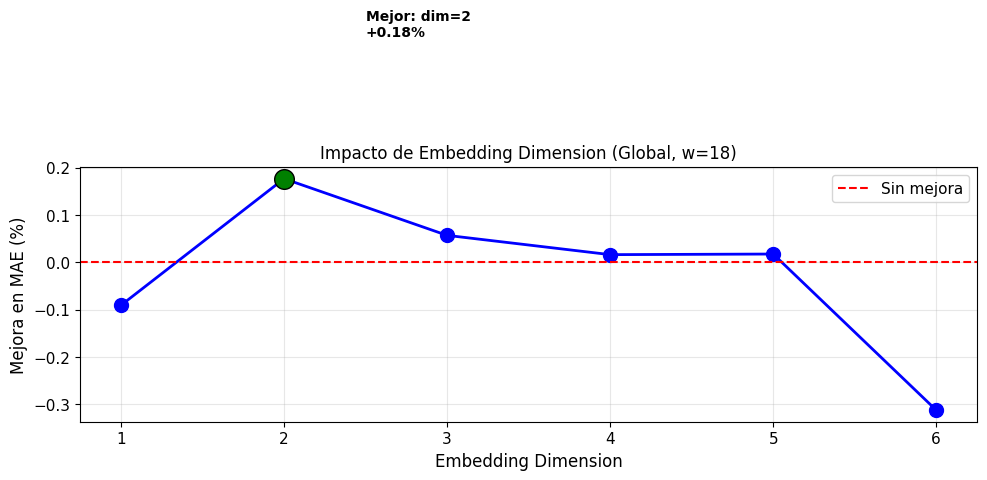


✅ MEJOR EMBEDDING_DIM GLOBAL: 2 (Mejora: +0.18%)


In [ ]:
# ============================================================
# OPTIMIZACIÓN DE EMBEDDING_DIM CON TODA LA SERIE
# ============================================================

print("\n" + "="*80)
print("🔬 ACTIVIDAD 5b: Optimización de Embedding Dim (Global)")
print("="*80)

# Usar el mejor window encontrado
print(f"Usando window_size = {best_window_global} meses")

embedding_dims = [1,2, 3, 4, 5, 6]
resultados_dim_global = []

print("\nProbando diferentes embedding_dim:")
print("="*60)

for dim in embedding_dims:
    # Verificar factibilidad
    min_points = (dim - 1) * 1 + 1
    if min_points > best_window_global:
        print(f"\n🔹 dim={dim}: ⚠ Requiere {min_points} pts, ventana={best_window_global} → NO VÁLIDO")
        resultados_dim_global.append({
            'dim': dim,
            'tda_mae': np.nan,
            'mejora': np.nan,
            'valido': False
        })
        continue
    
    print(f"\n🔹 Probando embedding_dim = {dim}...")
    
    # Baseline
    base = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                              window_size=best_window_global, use_tda=False)
    
    # Con TDA
    tda = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                             window_size=best_window_global, 
                             embedding_dim=dim, time_delay=1,
                             use_tda=True)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_dim_global.append({
        'dim': dim,
        'tda_mae': tda['mae'],
        'mejora': mejora,
        'valido': True
    })
    
    estado = "✅" if mejora > 0 else "❌"
    print(f"   TDA MAE: {tda['mae']:.4f}")
    print(f"   Mejora:  {estado} {mejora:+.4f}%")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

resultados_validos = [r for r in resultados_dim_global if r['valido']]
if resultados_validos:
    dims = [r['dim'] for r in resultados_validos]
    mejoras_dim = [r['mejora'] for r in resultados_validos]
    
    ax.plot(dims, mejoras_dim, 'bo-', linewidth=2, markersize=10)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Sin mejora')
    ax.set_xlabel('Embedding Dimension', fontsize=12)
    ax.set_ylabel('Mejora en MAE (%)', fontsize=12)
    ax.set_title(f'Impacto de Embedding Dimension (Global, w={best_window_global})', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    best_idx_dim = np.argmax(mejoras_dim)
    best_dim_global = dims[best_idx_dim]
    best_mejora_dim_global = mejoras_dim[best_idx_dim]
    
    ax.scatter([best_dim_global], [best_mejora_dim_global], c='green', s=200, zorder=5, edgecolors='black')
    ax.annotate(f'Mejor: dim={best_dim_global}\n{best_mejora_dim_global:+.2f}%', 
                xy=(best_dim_global, best_mejora_dim_global), 
                xytext=(best_dim_global+0.5, best_mejora_dim_global+0.3),
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ MEJOR EMBEDDING_DIM GLOBAL: {best_dim_global} (Mejora: {best_mejora_dim_global:+.2f}%)")
else:
    print("No hay resultados válidos. Aumenta window_size o reduce embedding_dim.")
    best_dim_global = 3


🔬 ACTIVIDAD 5c: Optimización de Time Delay (Global)
Usando window_size = 18 meses, embedding_dim = 2

Probando diferentes time_delays:

🔹 Probando τ = 1...
   TDA MAE: 41.8006
   Mejora:  ✅ +0.1766%

🔹 Probando τ = 2...
   TDA MAE: 42.1044
   Mejora:  ❌ -0.5490%

🔹 Probando τ = 3...
   TDA MAE: 42.0174
   Mejora:  ❌ -0.3412%

🔹 Probando τ = 4...
   TDA MAE: 41.8324
   Mejora:  ✅ +0.1005%

🔹 Probando τ = 5...
   TDA MAE: 42.0778
   Mejora:  ❌ -0.4855%


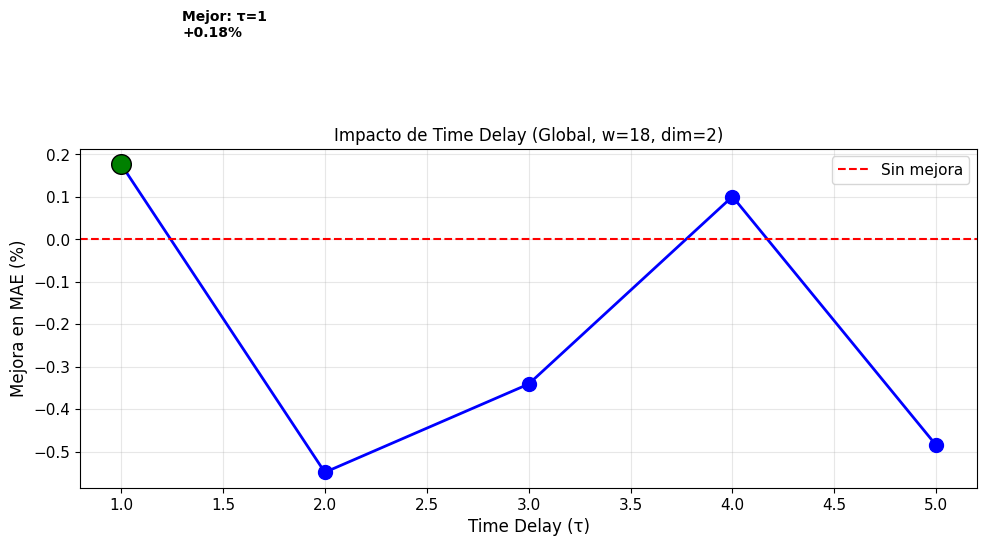


✅ MEJOR TIME_DELAY GLOBAL: τ=1 (Mejora: +0.18%)


In [ ]:
# ============================================================
# OPTIMIZACIÓN DE TIME_DELAY CON TODA LA SERIE
# ============================================================

print("\n" + "="*80)
print("🔬 ACTIVIDAD 5c: Optimización de Time Delay (Global)")
print("="*80)

print(f"Usando window_size = {best_window_global} meses, embedding_dim = {best_dim_global}")

time_delays = [1, 2, 3, 4, 5]
resultados_delay_global = []

print("\nProbando diferentes time_delays:")
print("="*60)

for delay in time_delays:
    # Verificar factibilidad
    min_points = (best_dim_global - 1) * delay + 1
    if min_points > best_window_global:
        print(f"\n🔹 τ={delay}: ⚠ Requiere {min_points} pts, ventana={best_window_global} → NO VÁLIDO")
        resultados_delay_global.append({
            'delay': delay,
            'tda_mae': np.nan,
            'mejora': np.nan,
            'valido': False
        })
        continue
    
    print(f"\n🔹 Probando τ = {delay}...")
    
    # Baseline
    base = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                              window_size=best_window_global, use_tda=False)
    
    # Con TDA
    tda = entrenar_y_evaluar(signal_global_entreno_opt, signal_global_prueba_opt,
                             window_size=best_window_global,
                             embedding_dim=best_dim_global,
                             time_delay=delay,
                             use_tda=True)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_delay_global.append({
        'delay': delay,
        'tda_mae': tda['mae'],
        'mejora': mejora,
        'valido': True
    })
    
    estado = "✅" if mejora > 0 else "❌"
    print(f"   TDA MAE: {tda['mae']:.4f}")
    print(f"   Mejora:  {estado} {mejora:+.4f}%")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

resultados_validos = [r for r in resultados_delay_global if r['valido']]
if resultados_validos:
    delays = [r['delay'] for r in resultados_validos]
    mejoras_delay = [r['mejora'] for r in resultados_validos]
    
    ax.plot(delays, mejoras_delay, 'bo-', linewidth=2, markersize=10)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Sin mejora')
    ax.set_xlabel('Time Delay (τ)', fontsize=12)
    ax.set_ylabel('Mejora en MAE (%)', fontsize=12)
    ax.set_title(f'Impacto de Time Delay (Global, w={best_window_global}, dim={best_dim_global})', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    best_idx_delay = np.argmax(mejoras_delay)
    best_delay_global = delays[best_idx_delay]
    best_mejora_delay_global = mejoras_delay[best_idx_delay]
    
    ax.scatter([best_delay_global], [best_mejora_delay_global], c='green', s=200, zorder=5, edgecolors='black')
    ax.annotate(f'Mejor: τ={best_delay_global}\n{best_mejora_delay_global:+.2f}%', 
                xy=(best_delay_global, best_mejora_delay_global), 
                xytext=(best_delay_global+0.3, best_mejora_delay_global+0.3),
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ MEJOR TIME_DELAY GLOBAL: τ={best_delay_global} (Mejora: {best_mejora_delay_global:+.2f}%)")
else:
    print("No hay resultados válidos. Aumenta window_size o reduce embedding_dim.")
    best_delay_global = 1

In [ ]:
# ============================================================
# PARÁMETROS ÓPTIMOS GLOBALES (FINALES)
# ============================================================

print("\n" + "="*80)
print("🏆 PARÁMETROS ÓPTIMOS GLOBALES (Entrenamiento con toda la serie)")
print("="*80)

# Usar los mejores parámetros encontrados en la optimización global
OPTIMAL_WINDOW_GLOBAL = best_window_global
OPTIMAL_DIM_GLOBAL = best_dim_global
OPTIMAL_DELAY_GLOBAL = best_delay_global

print(f"""
                 PARÁMETROS OPTIMIZADOS CON TODA LA SERIE                   
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║   window_size  = {OPTIMAL_WINDOW_GLOBAL} meses                                ║
║   embedding_dim = {OPTIMAL_DIM_GLOBAL}                                        ║
║   time_delay    = {OPTIMAL_DELAY_GLOBAL}                                      ║
║                                                                               ║
║   Validación: Entreno 2008-2024 → Prueba 2025-2026                            ║
║   Mejora obtenida: {best_mejora_dim_global:+.2f}% (en periodo de prueba)      ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# Comparación con parámetros anteriores
print("\n📊 COMPARACIÓN CON PARÁMETROS ANTERIORES:")
print("-"*60)
print(f"   Parámetros por moda (antes): w=30, dim=4, τ=1")
print(f"   Parámetros optimizados global: w={OPTIMAL_WINDOW_GLOBAL}, dim={OPTIMAL_DIM_GLOBAL}, τ={OPTIMAL_DELAY_GLOBAL}")
print(f"   Diferencia: {abs(OPTIMAL_WINDOW_GLOBAL - 30)} meses de diferencia en window_size")


🏆 PARÁMETROS ÓPTIMOS GLOBALES (Entrenamiento con toda la serie)

                 PARÁMETROS OPTIMIZADOS CON TODA LA SERIE                   
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║   window_size  = 18 meses                                ║
║   embedding_dim = 2                                        ║
║   time_delay    = 1                                      ║
║                                                                               ║
║   Validación: Entreno 2008-2024 → Prueba 2025-2026                            ║
║   Mejora obtenida: +0.18% (en periodo de prueba)      ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝


📊 COMPARACIÓN CON PARÁMETROS ANTERIORES:
------------------------------------------------------------
   Parámetros por 